In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
# Set random seed for reproducibility
np.random.seed(101214)
n_participants = 100
prices = np.array([0.01, 0.05, 0.25, 1, 5, 10, 33, 100, 250, 500, 1000])  # prices in dollars

# Generate random parameters for each participant
Q0_values = np.random.uniform(20, 100, n_participants)  # maximum consumption
a_values = np.random.uniform(0.05, 0.25, n_participants)  # elasticity

# Store all data
all_data = []

# Generate consumption data for each participant
for participant in range(n_participants):
    Q0 = Q0_values[participant]
    a = a_values[participant]
    k = 1
    
    for price in prices:
        # Exponential demand function: Q = Q0 * exp(-a * P)
        if price >100:
            quantity = 0
        else:
            quantity = np.log(Q0) + k * (np.exp(-a * price)-1)
            quantity = np.exp(quantity)
            quantity += np.random.normal(-0.1*quantity, 0.1*quantity)  # add some noise
            quantity = max(quantity, 0)  # avoid negative consumption

        all_data.append({
            'participant_id': participant + 1,
            'Q0': Q0,
            'a': a,
            'price': price,
            'consumption': quantity
        })

# Convert to DataFrame
df = pd.DataFrame(all_data)


pivot_df = df.pivot(index='participant_id', columns='price', values='consumption').reset_index()
pivot_df = df.pivot(index='participant_id', columns='price', values='consumption')

pivot_df.columns = [f"price_{p:.2f}" for p in pivot_df.columns]
pivot_df


params = df.groupby('participant_id')[['Q0', 'a']].first()
pivot_df = pivot_df.merge(params, left_index=True, right_index=True)
pivot_df = pivot_df[[col for col in pivot_df.columns if 'price' in col] + ['Q0', 'a']]
pivot_df.reset_index(inplace=True)
pivot_df.to_csv("participant_data.csv", index=False)

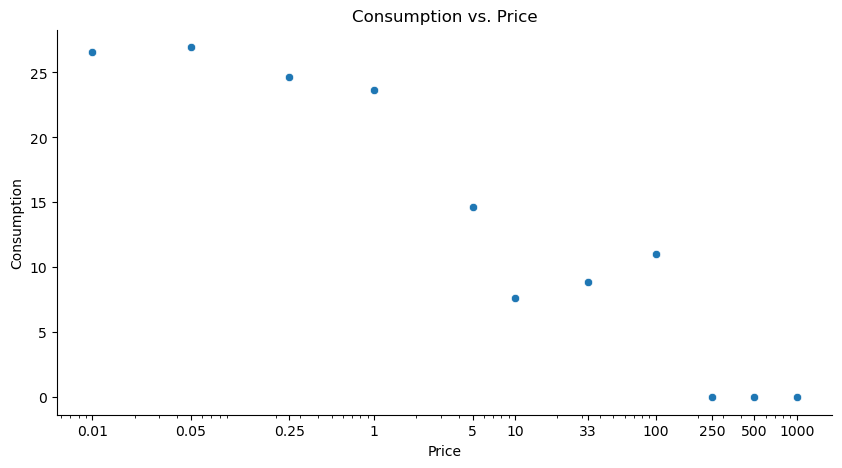

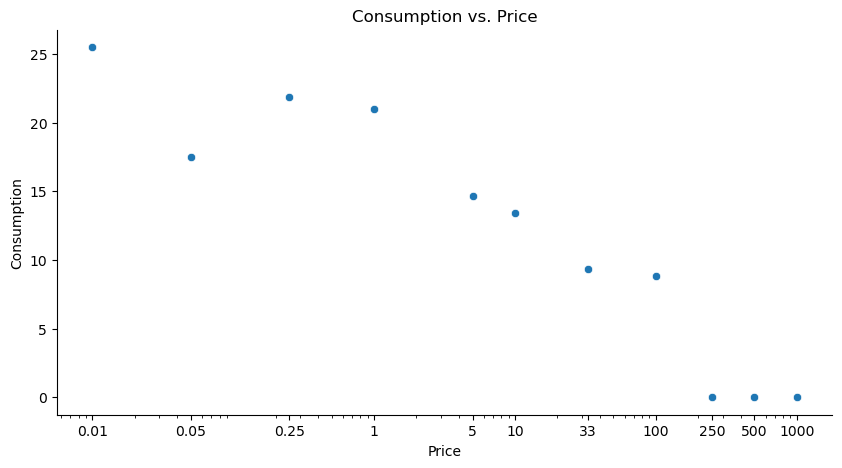

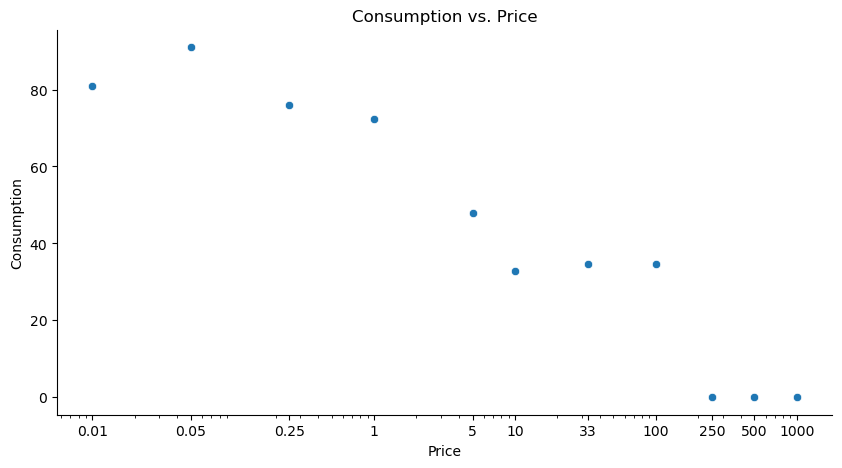

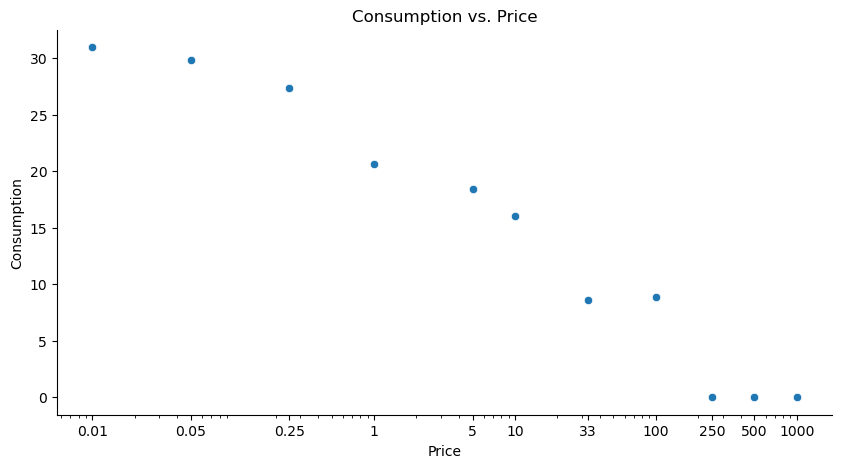

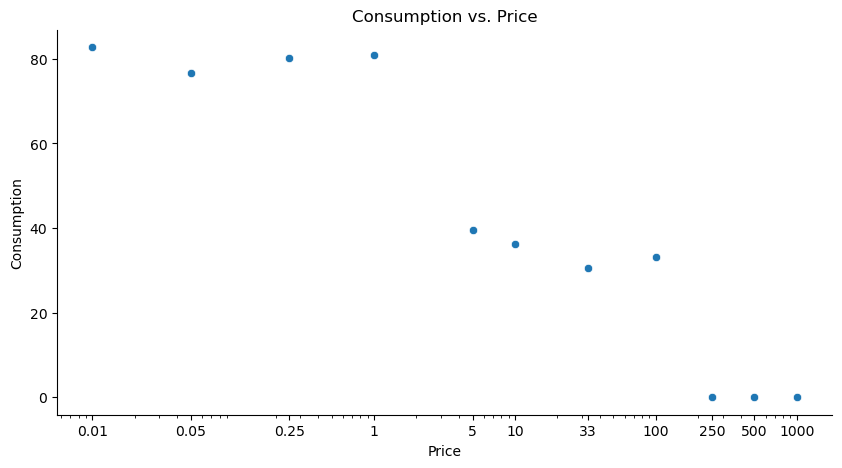

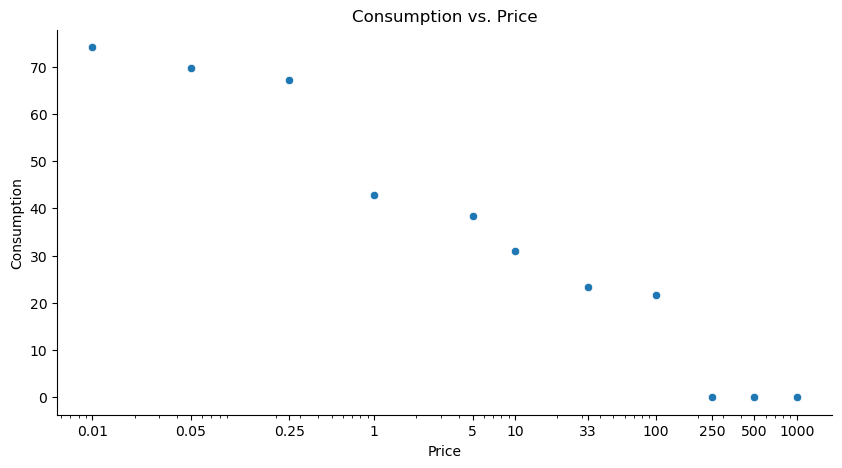

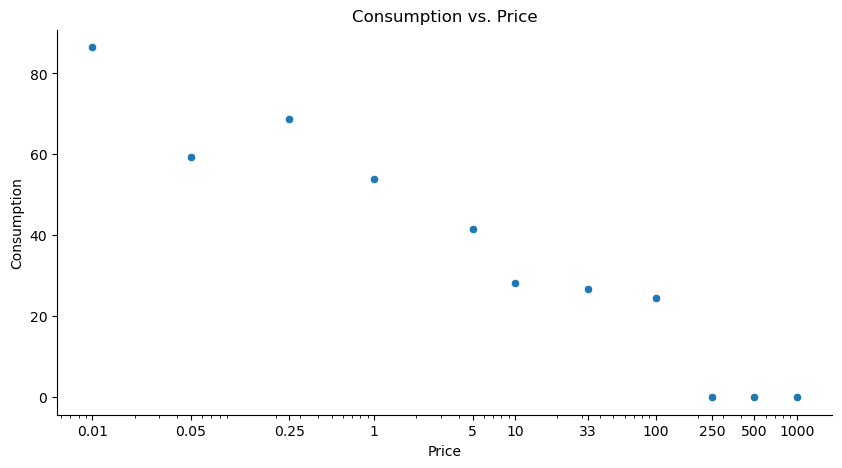

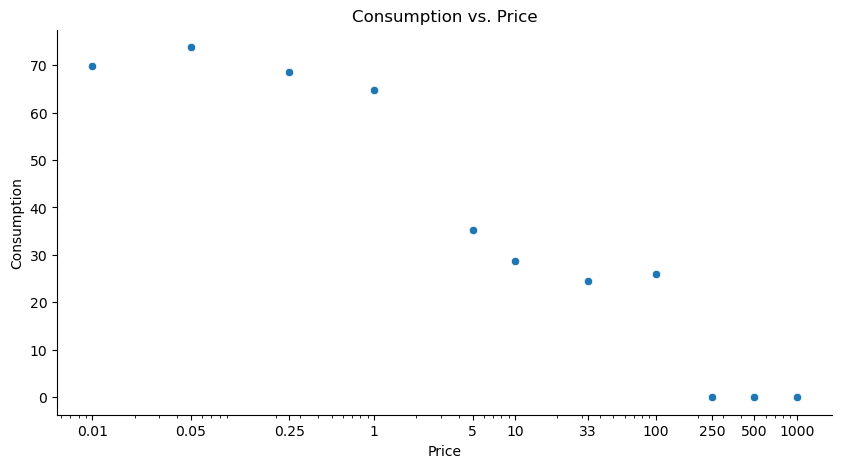

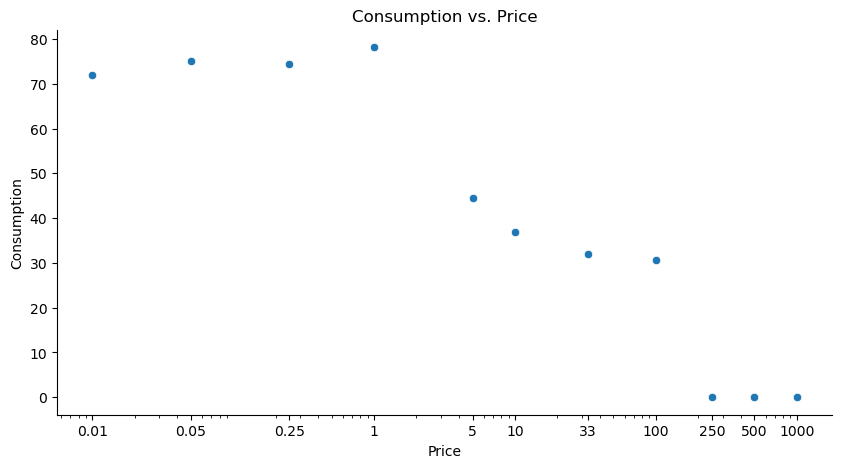

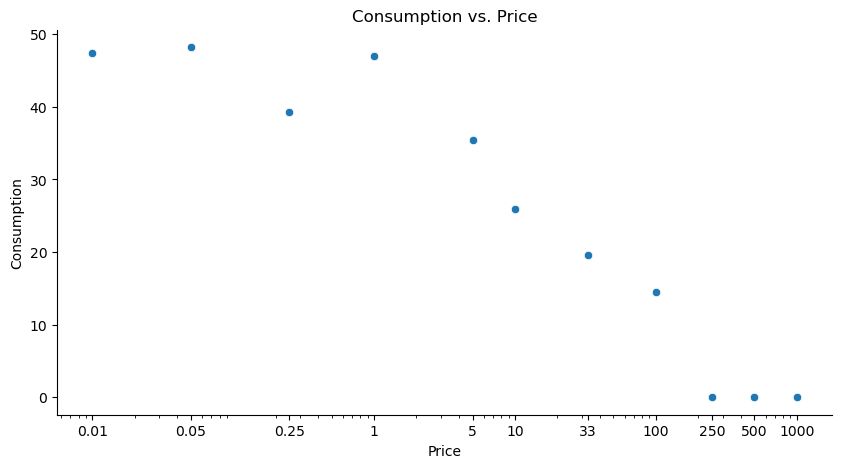

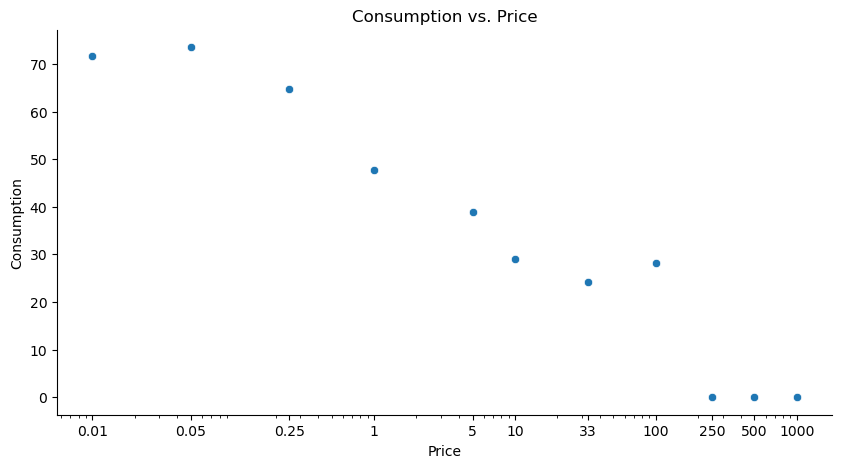

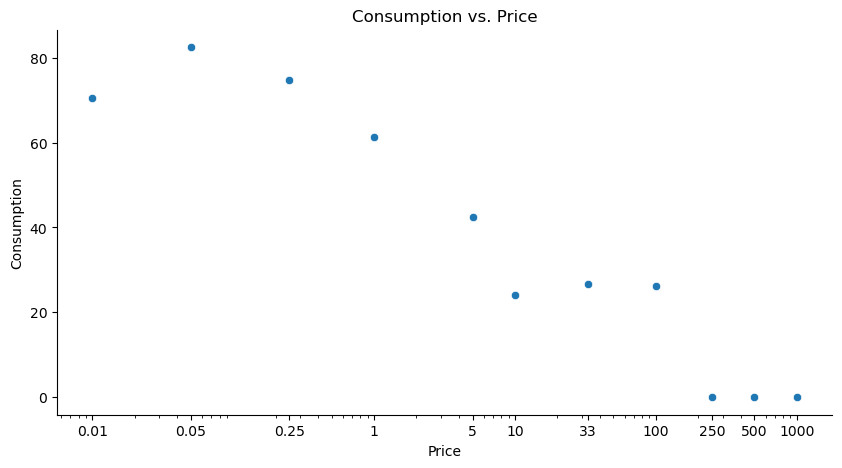

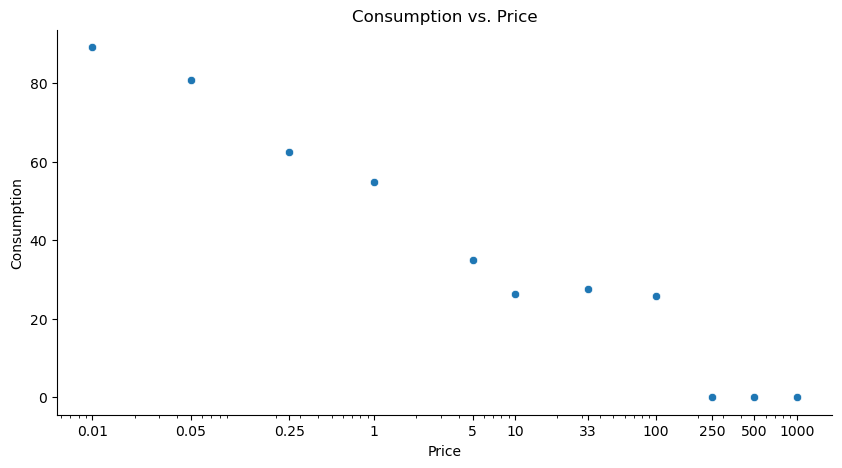

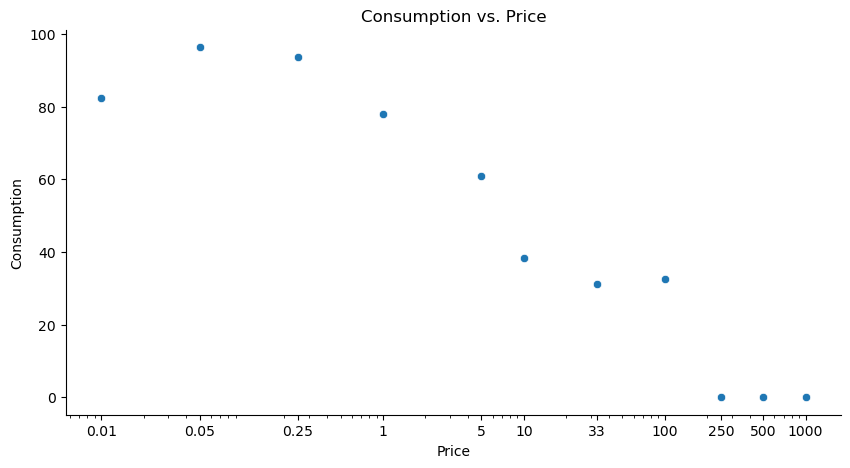

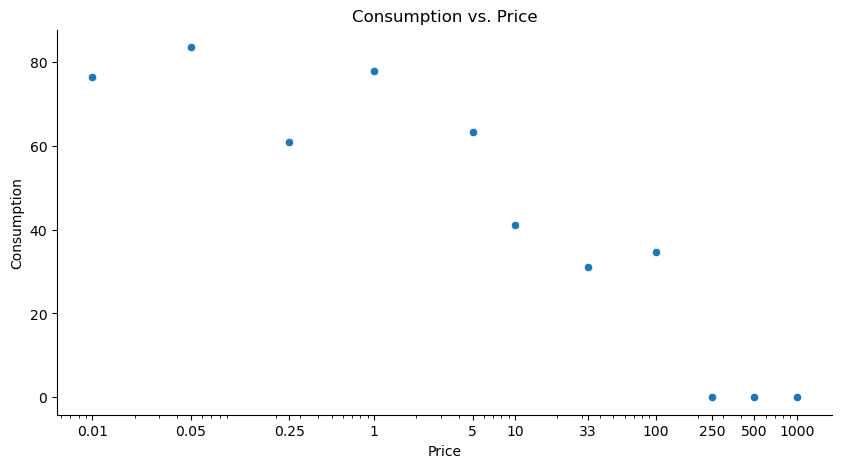

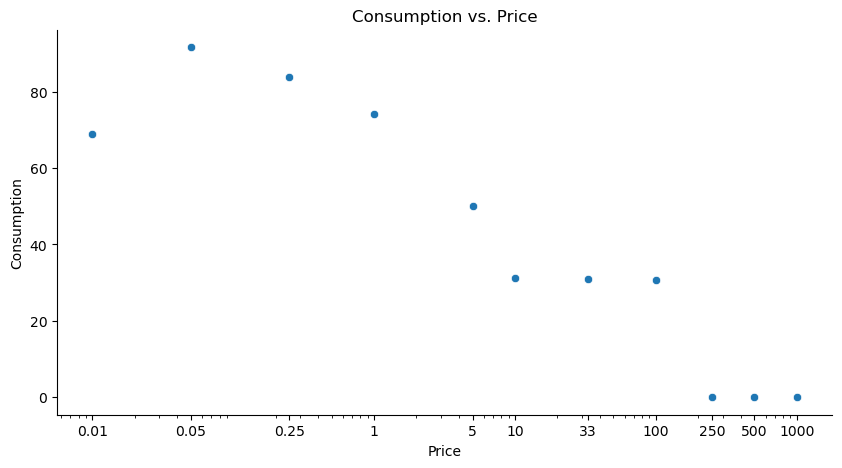

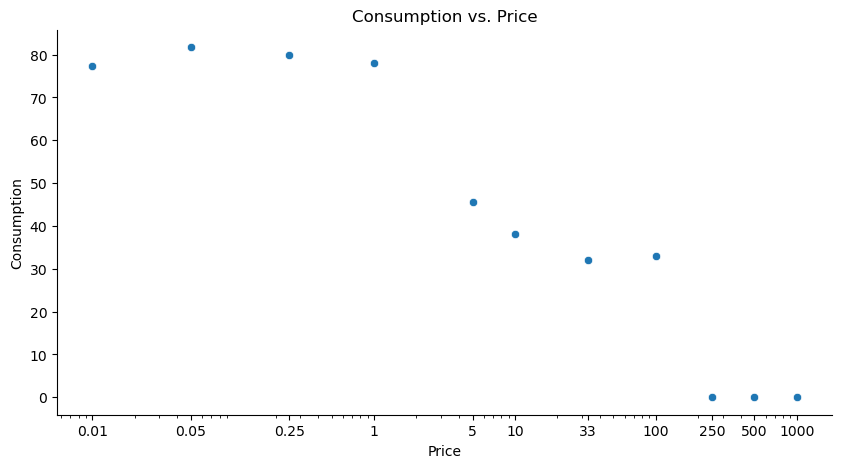

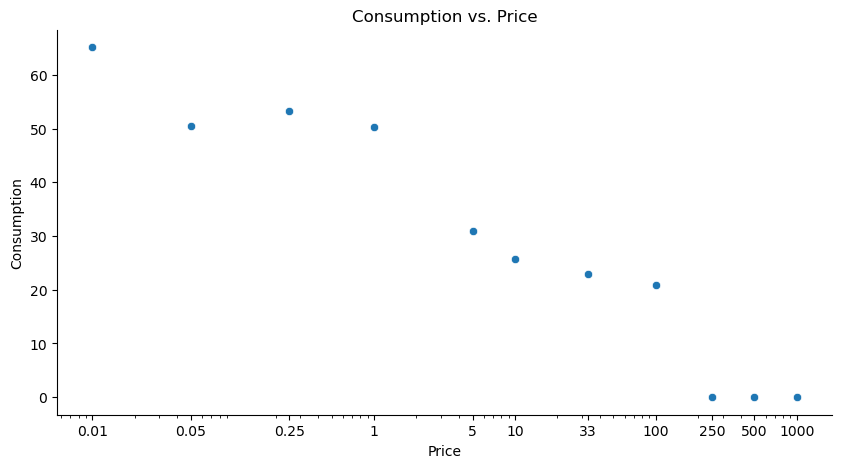

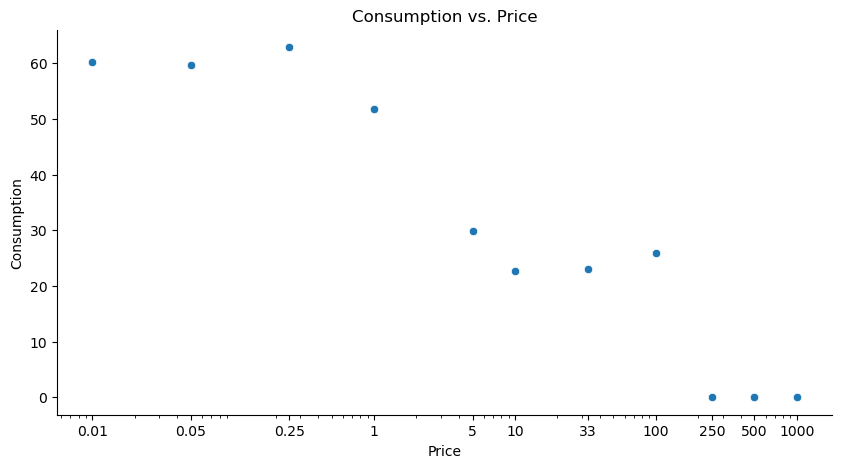

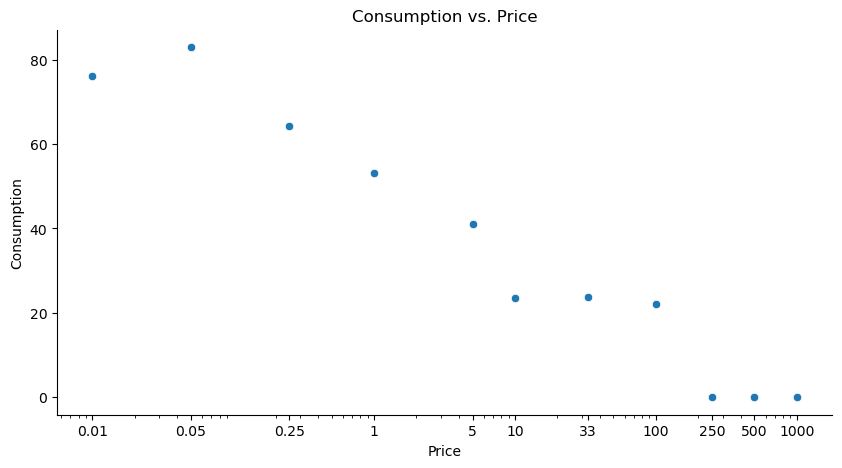

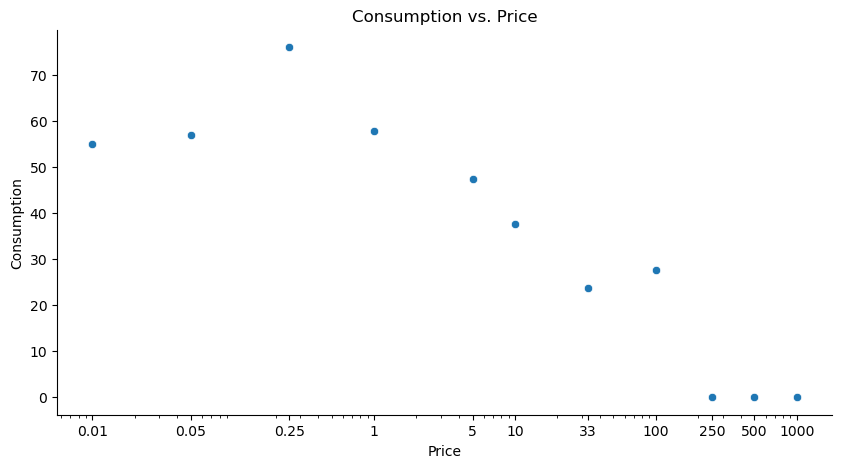

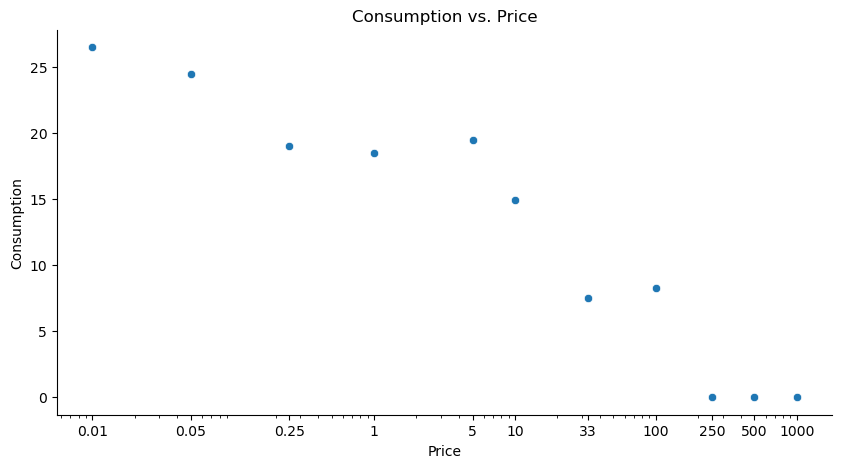

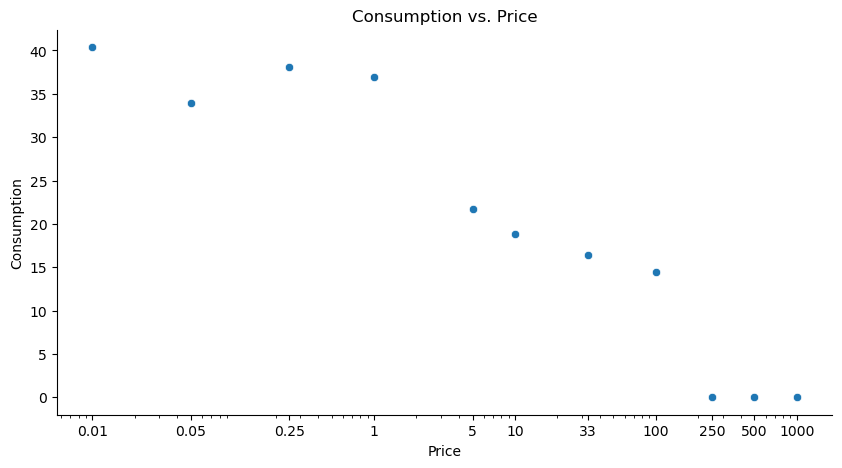

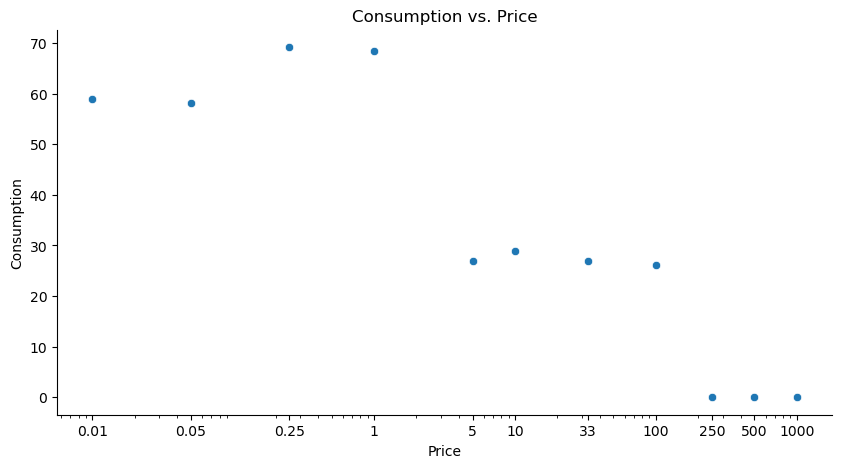

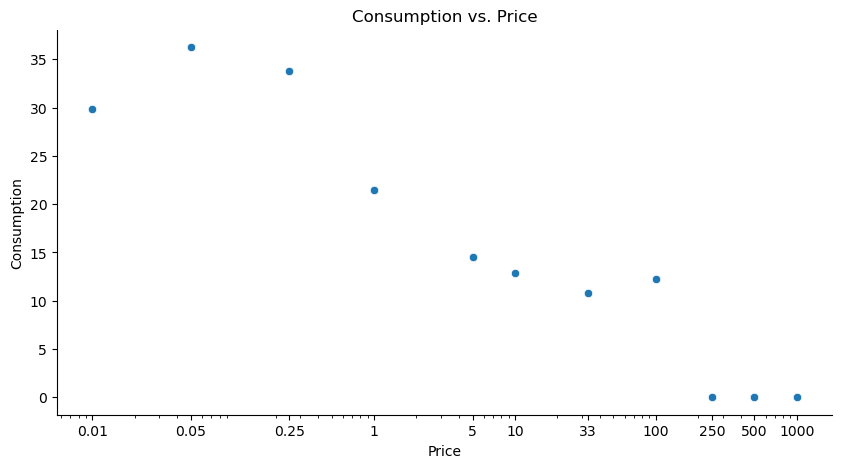

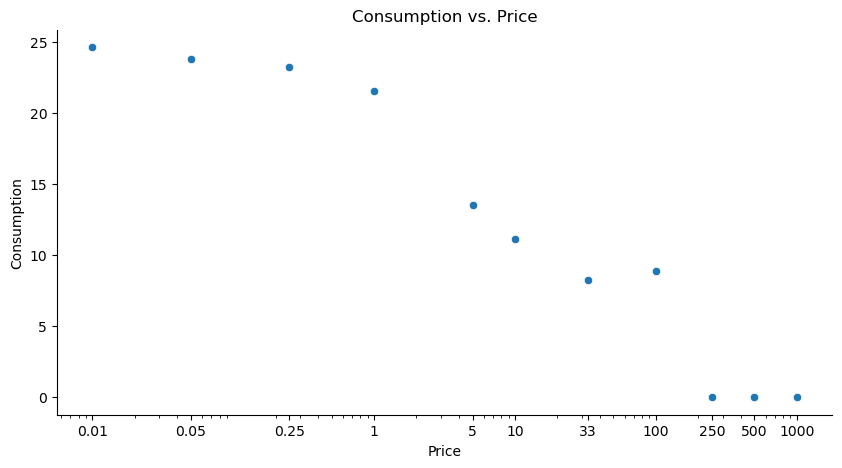

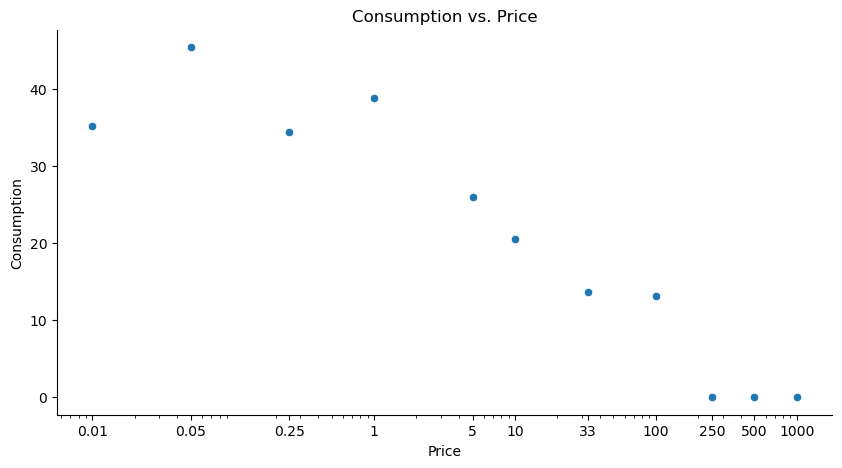

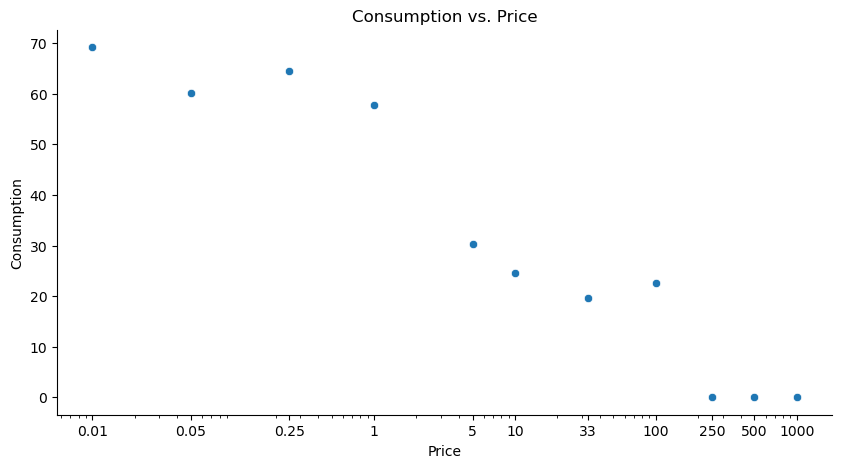

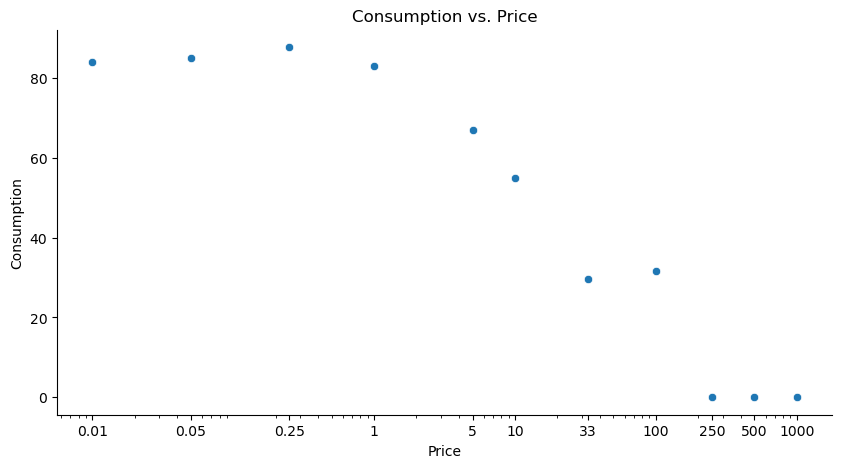

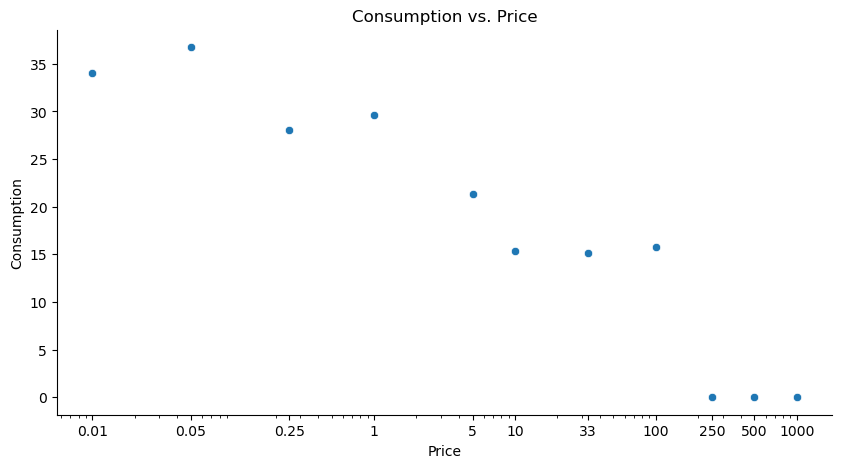

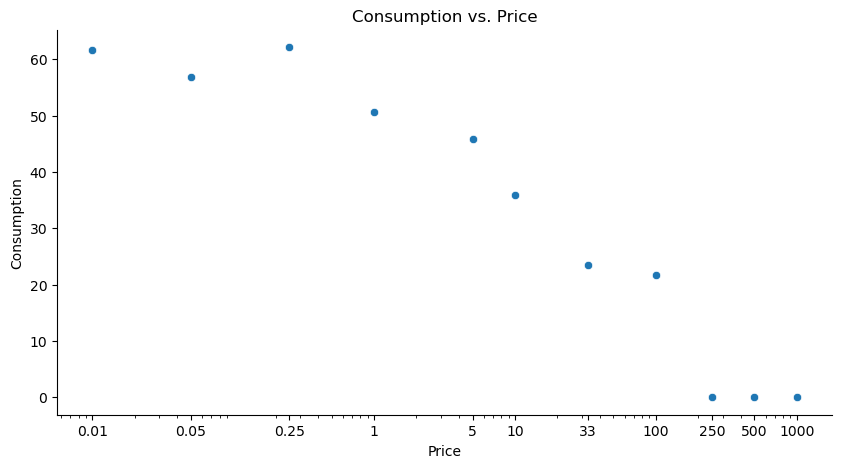

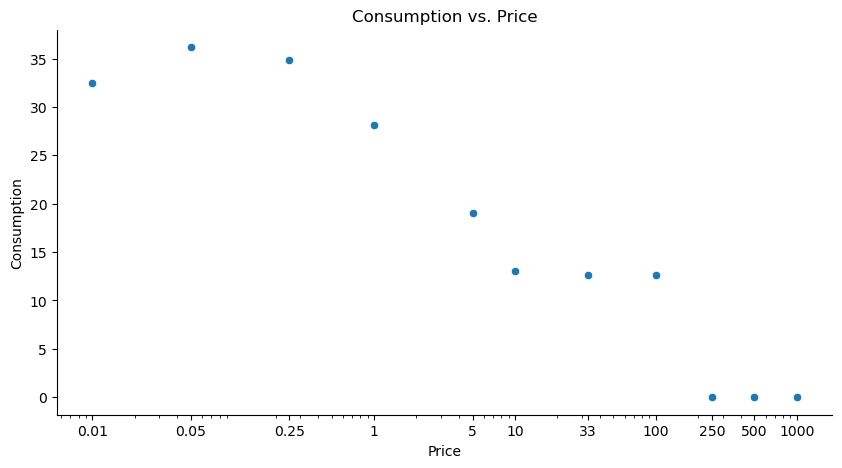

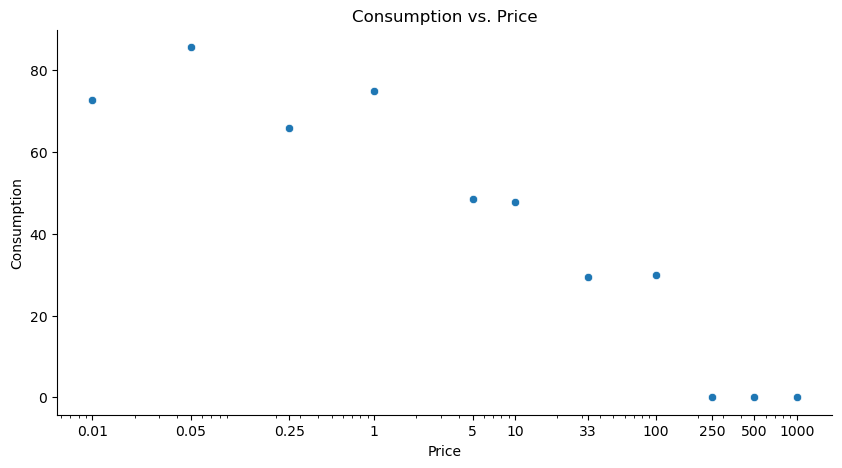

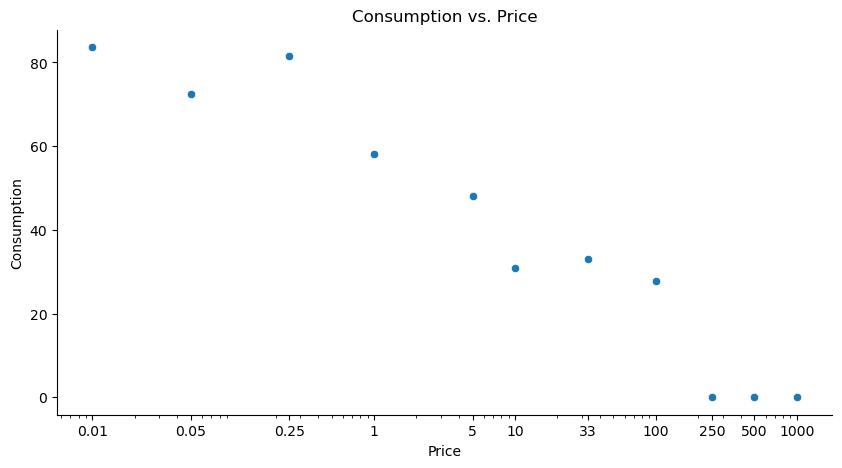

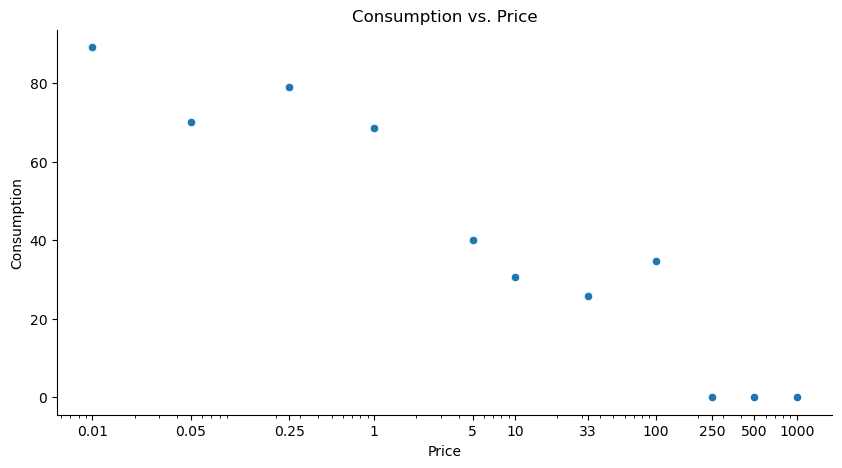

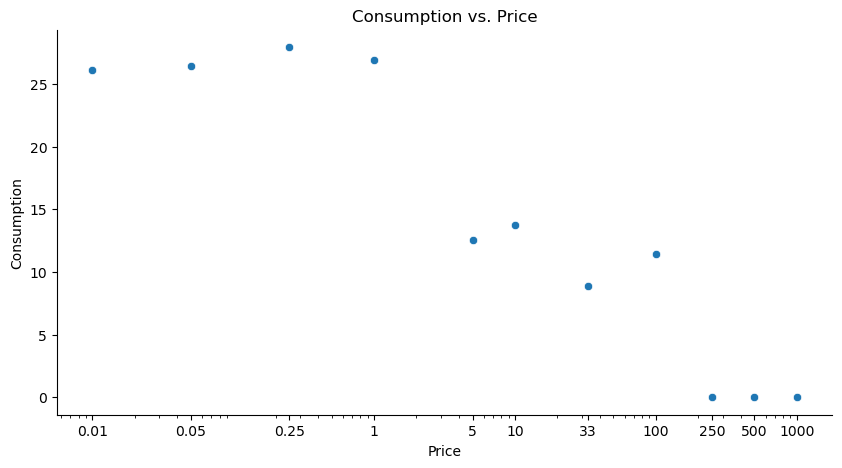

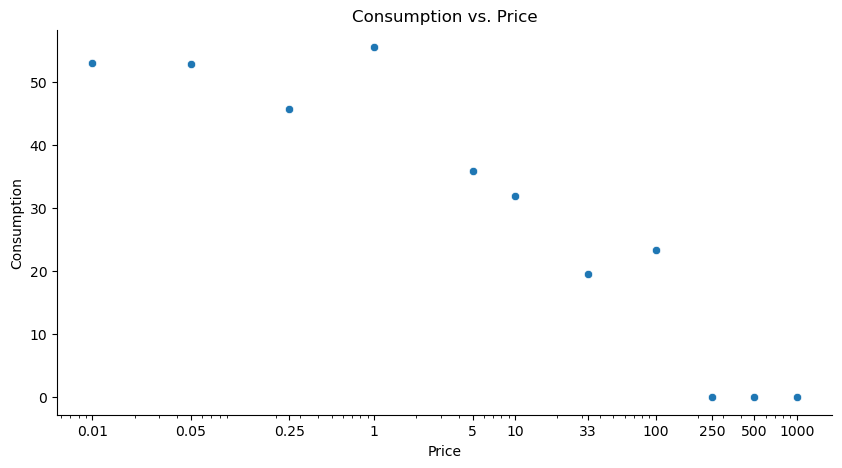

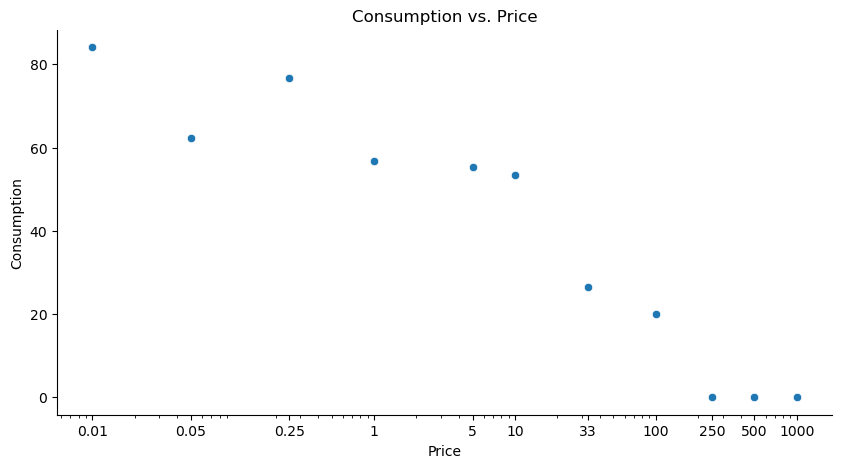

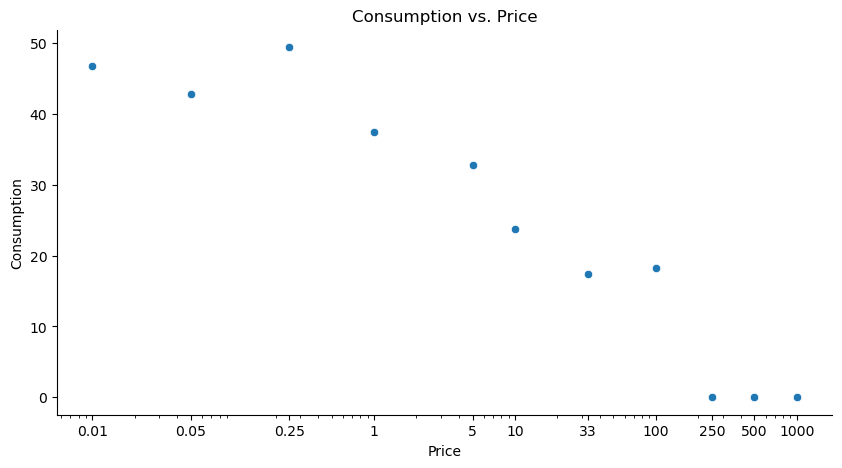

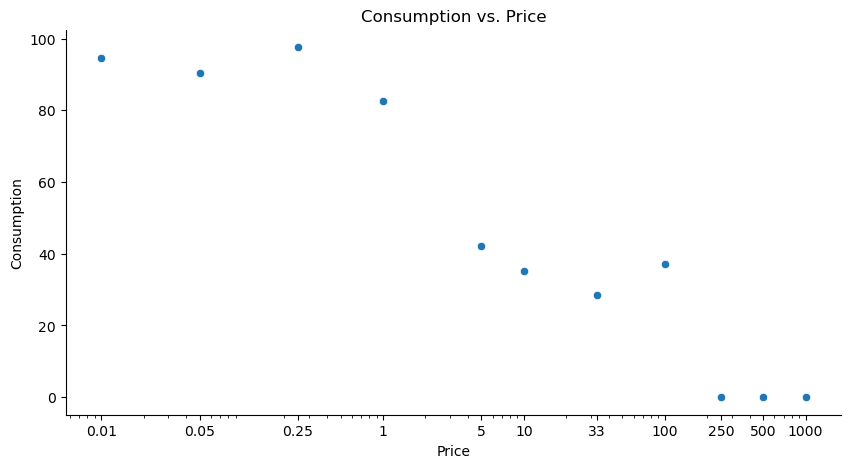

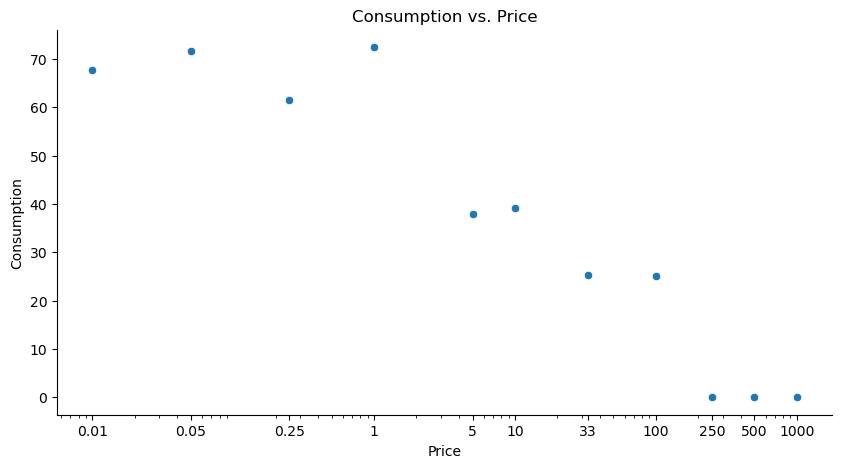

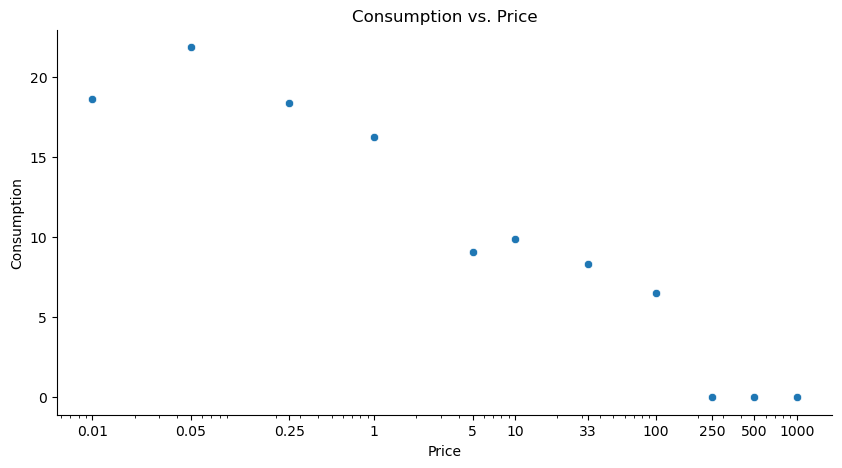

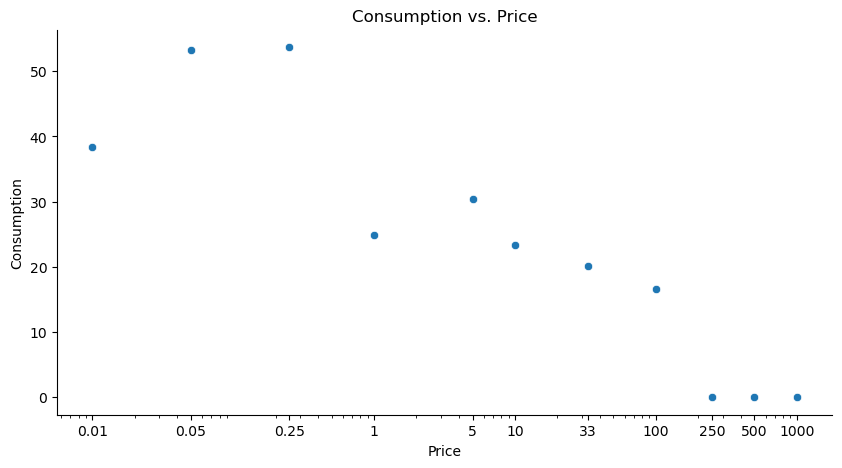

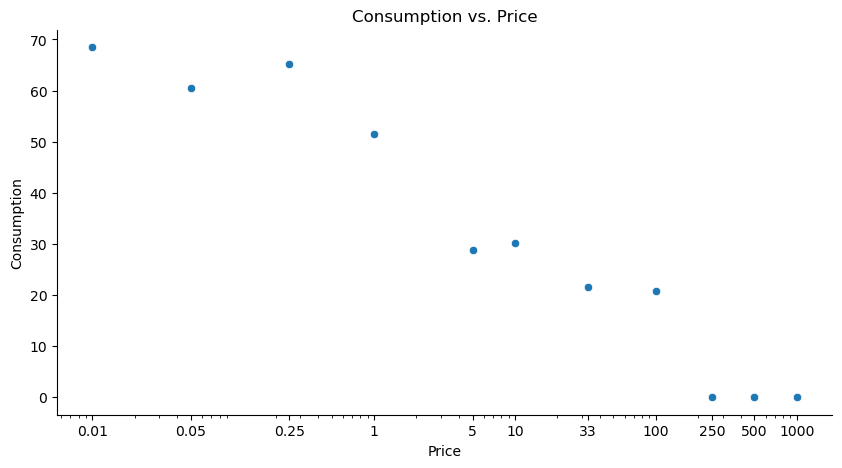

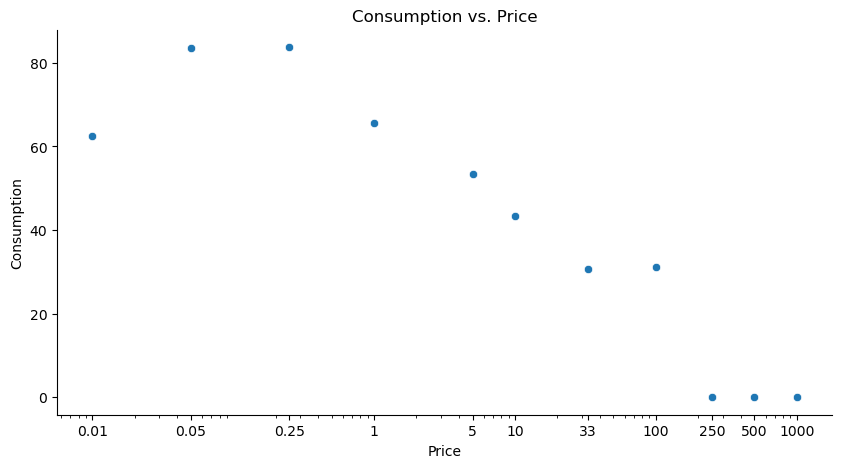

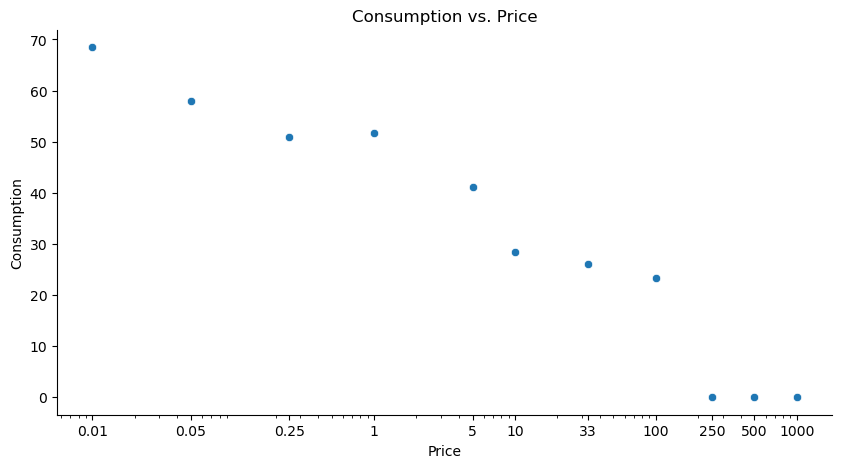

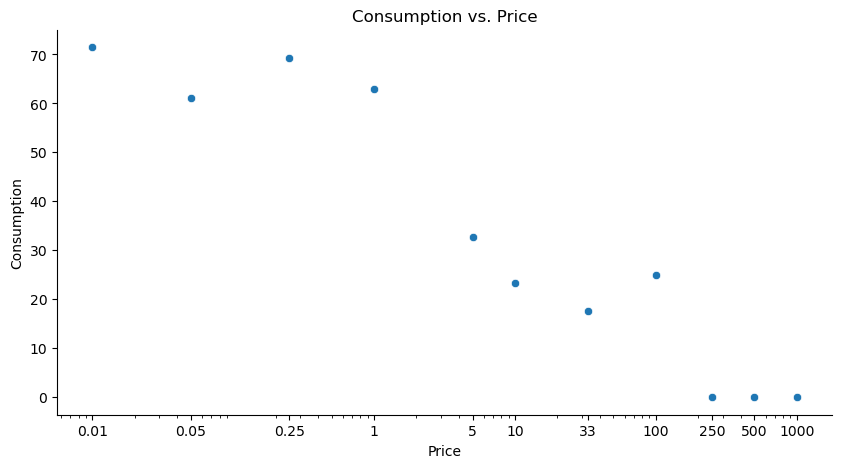

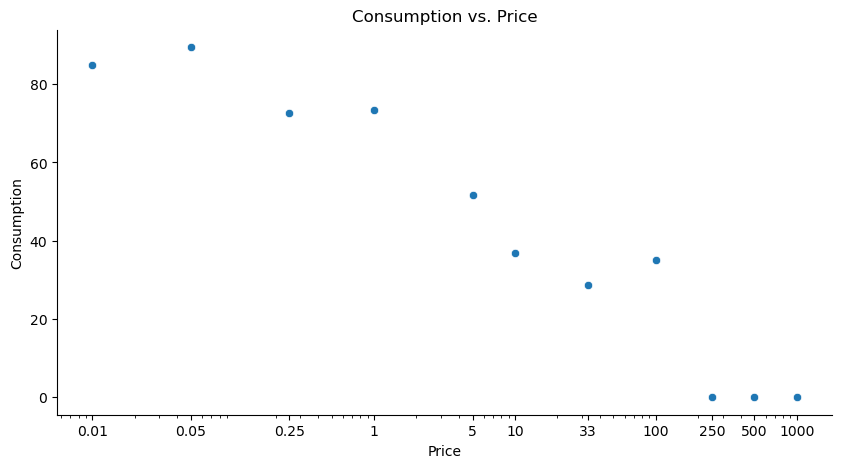

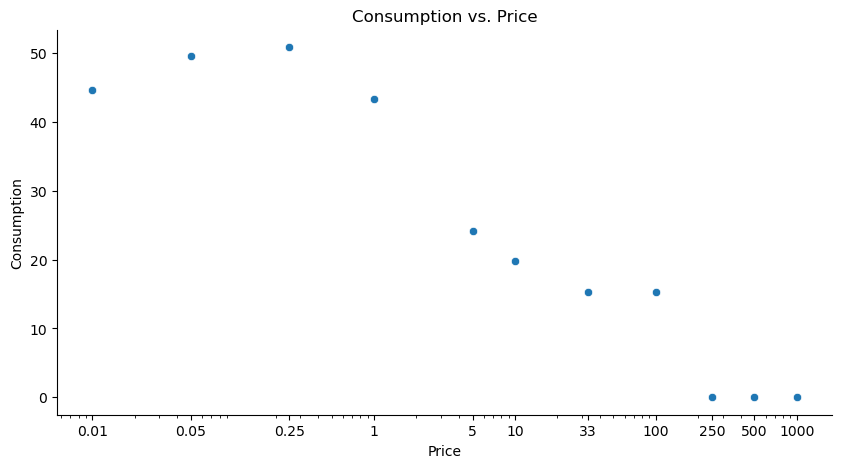

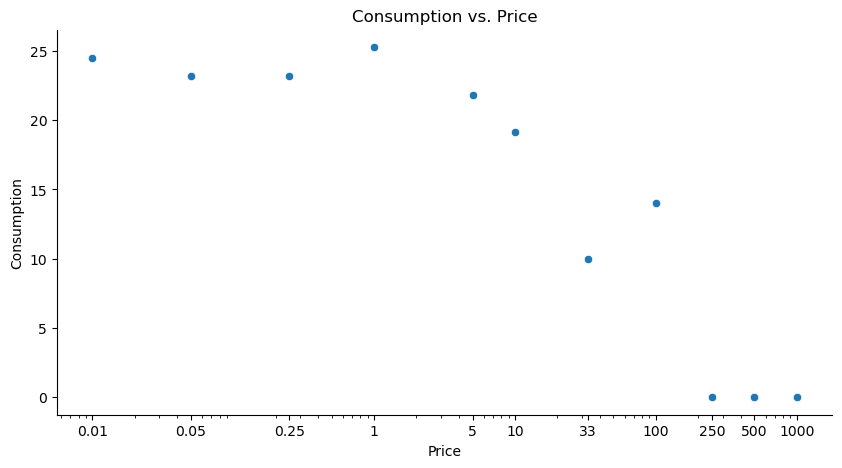

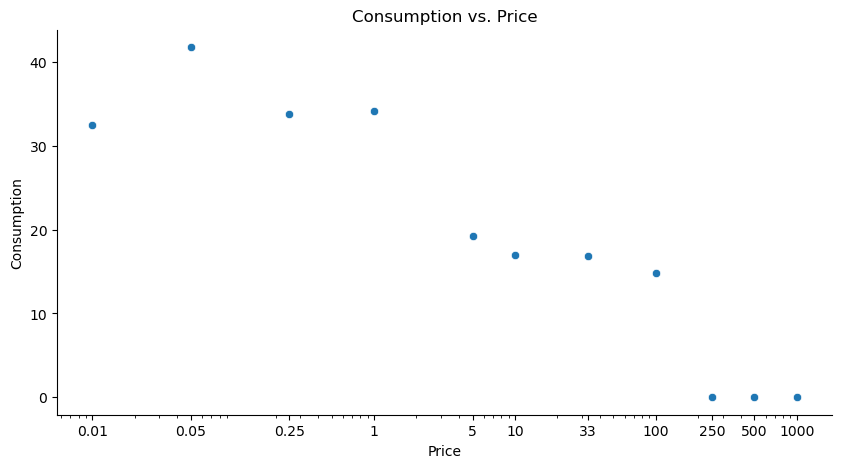

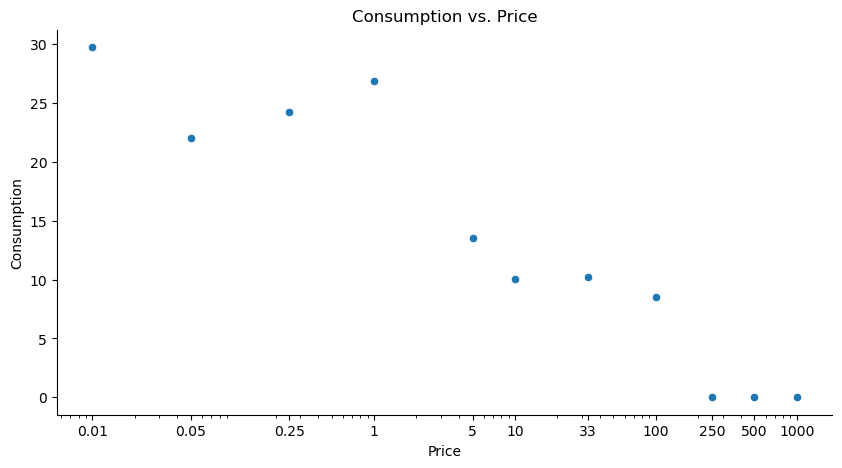

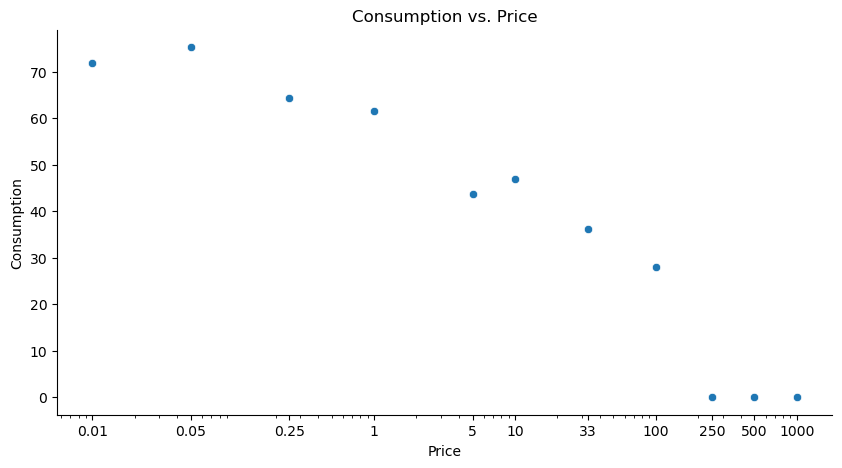

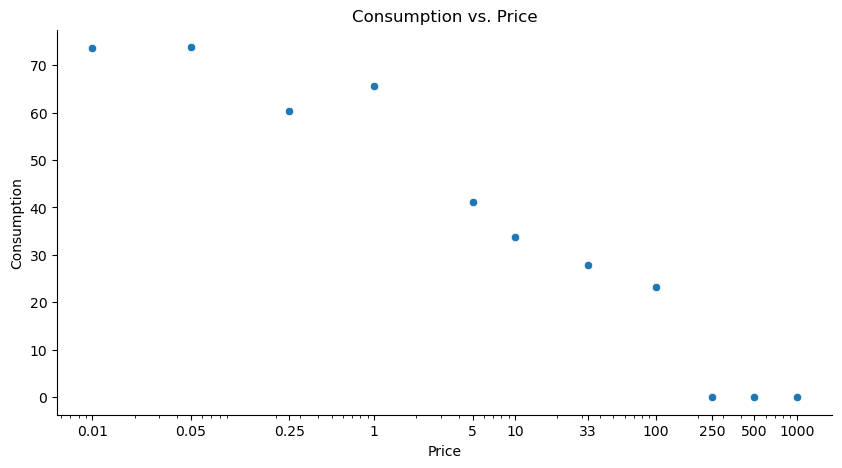

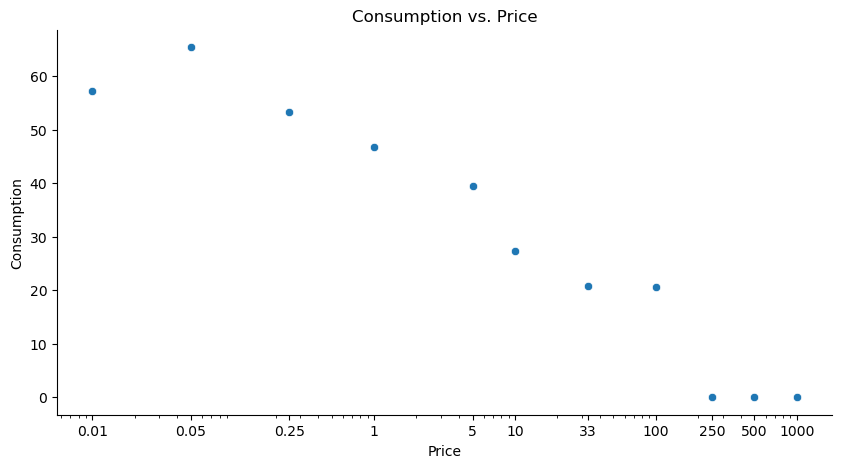

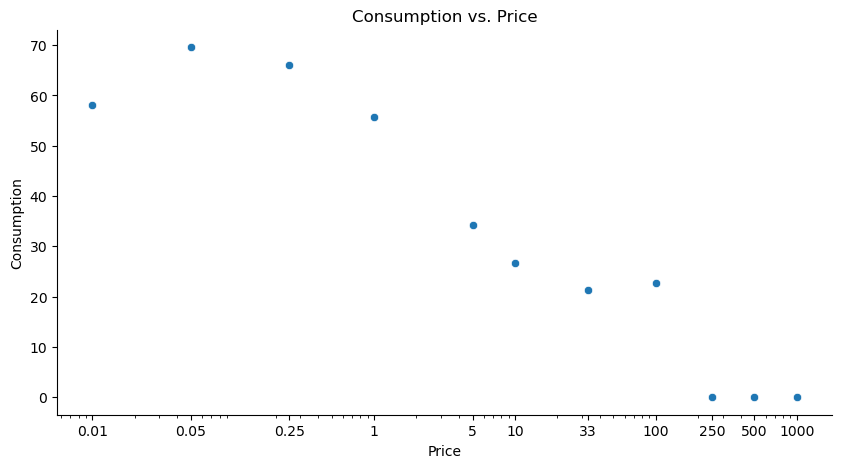

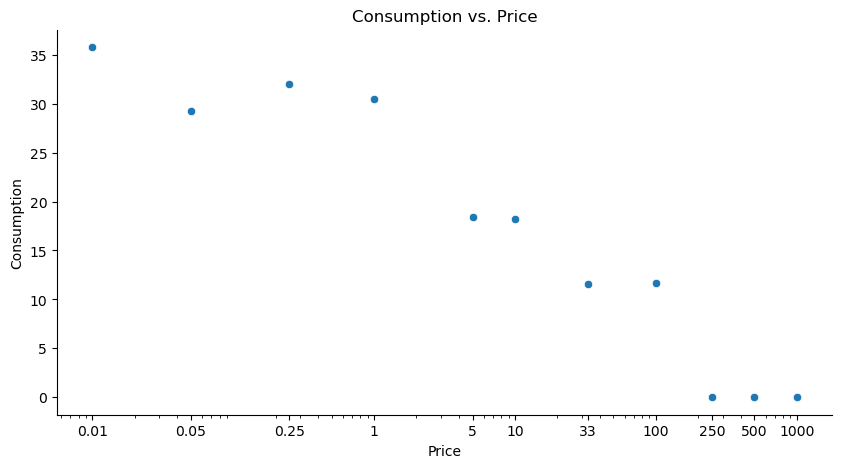

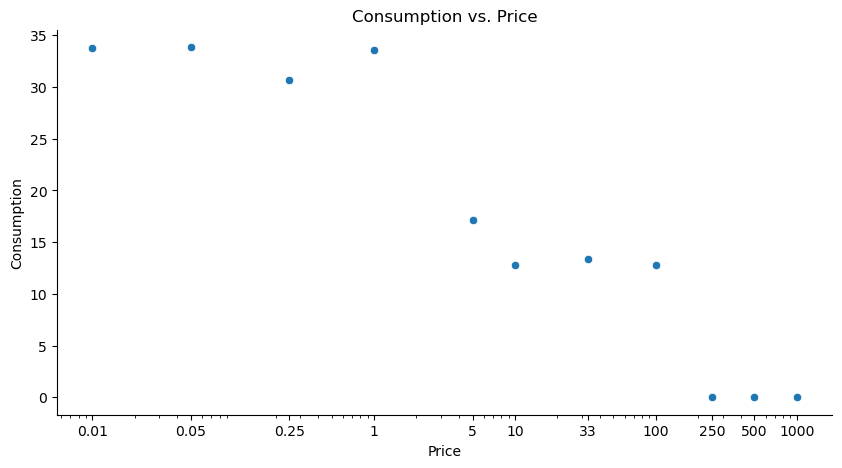

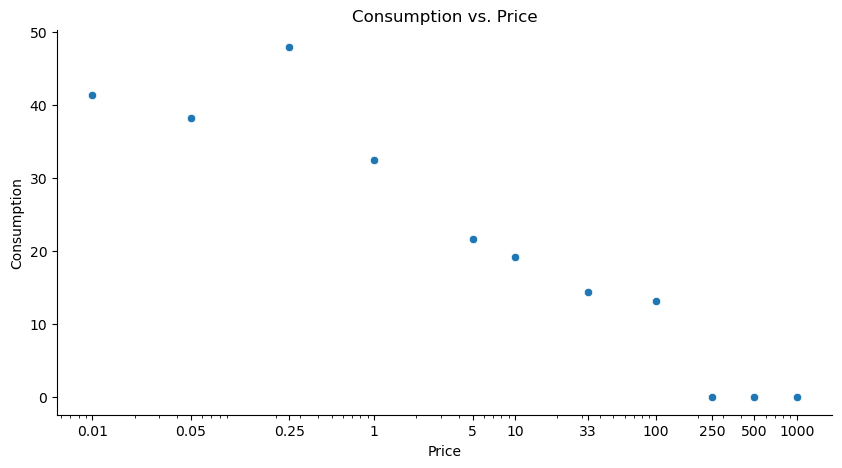

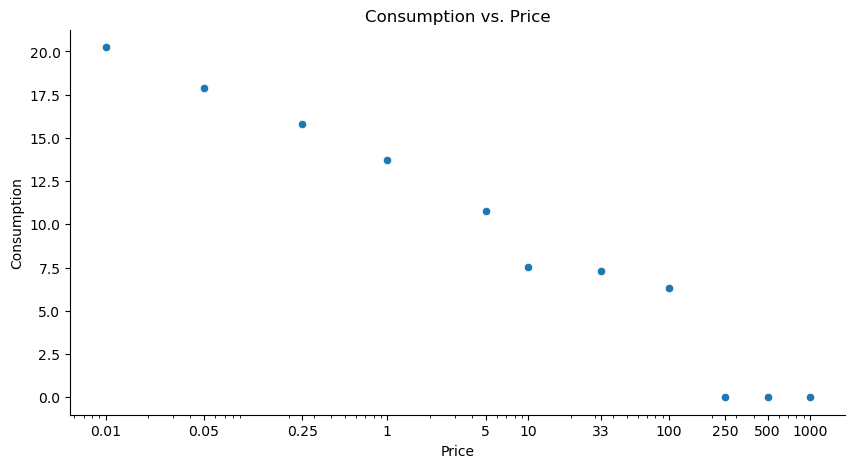

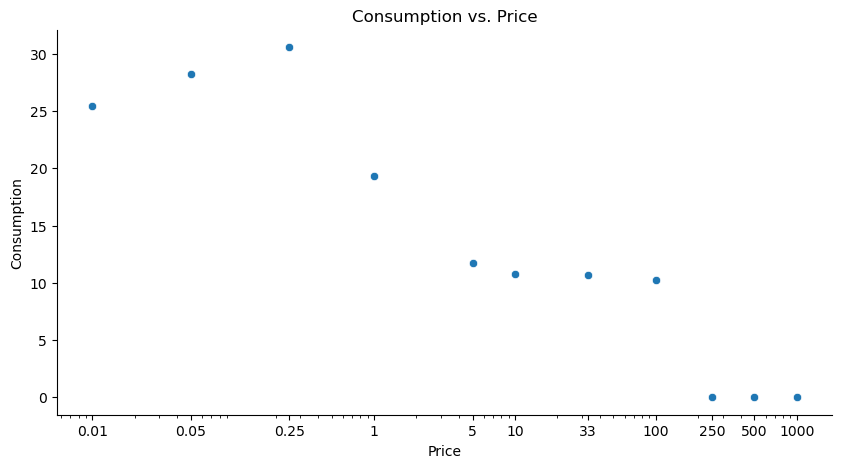

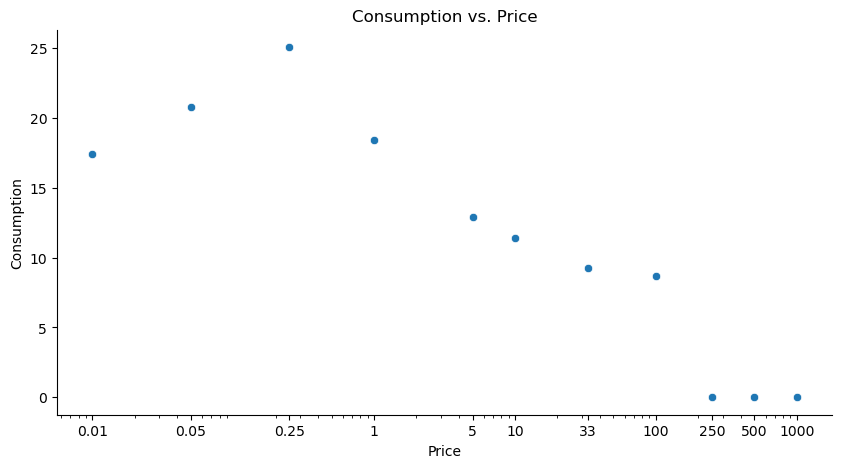

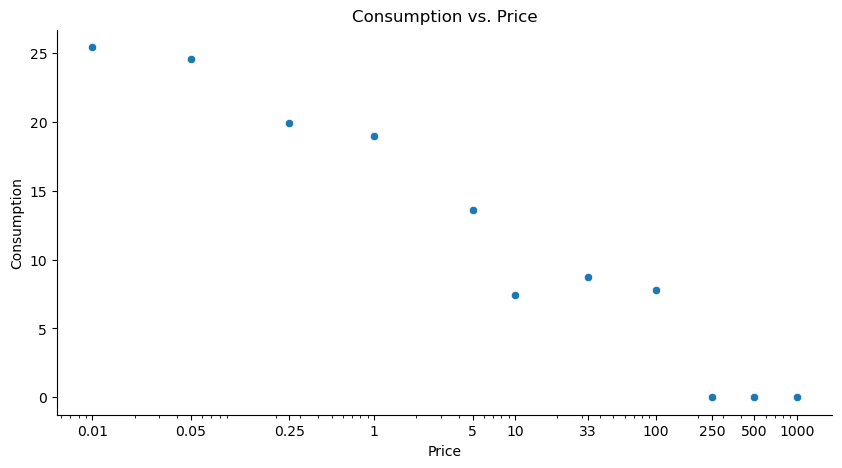

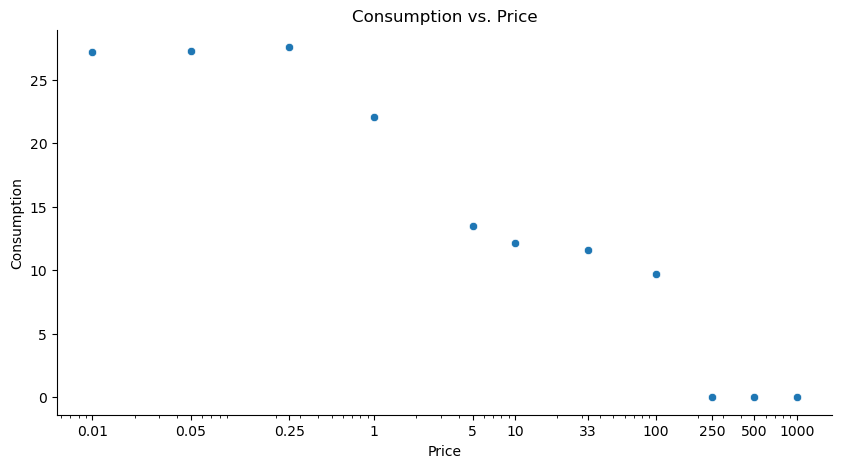

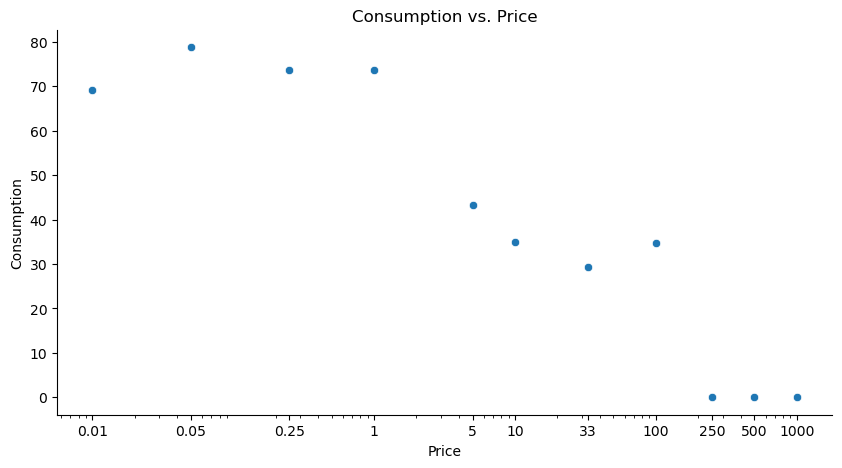

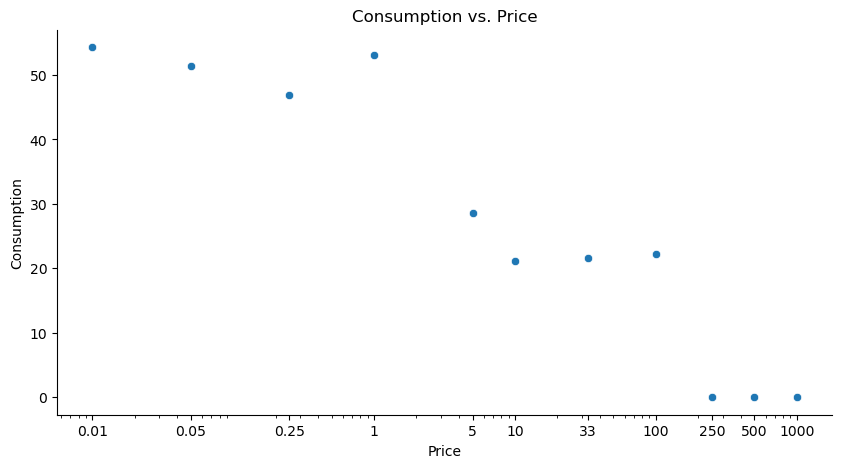

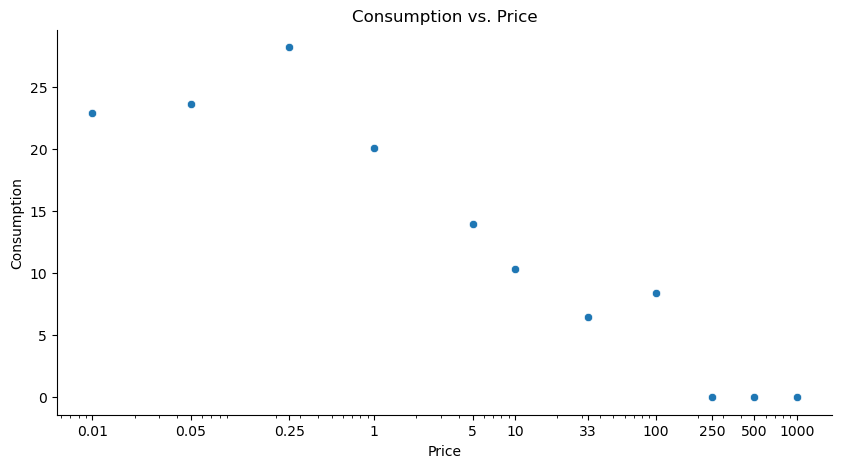

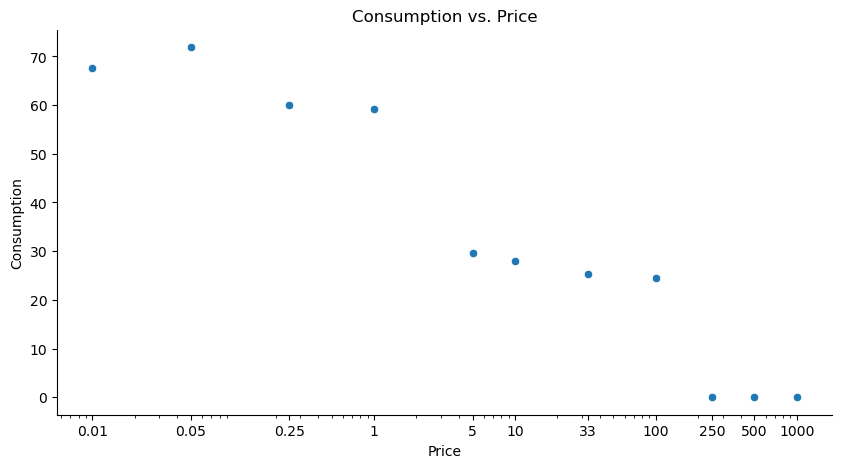

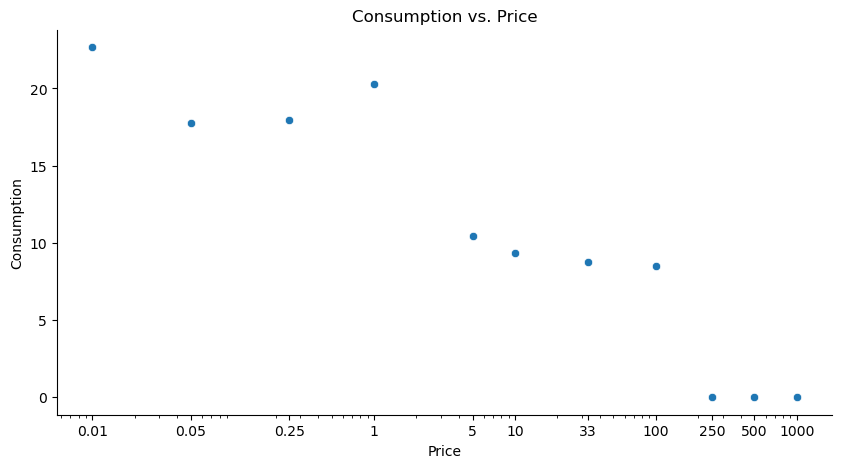

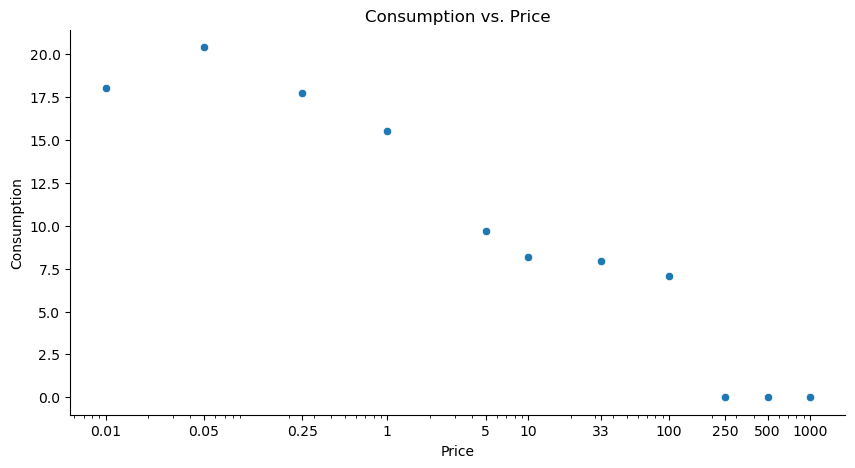

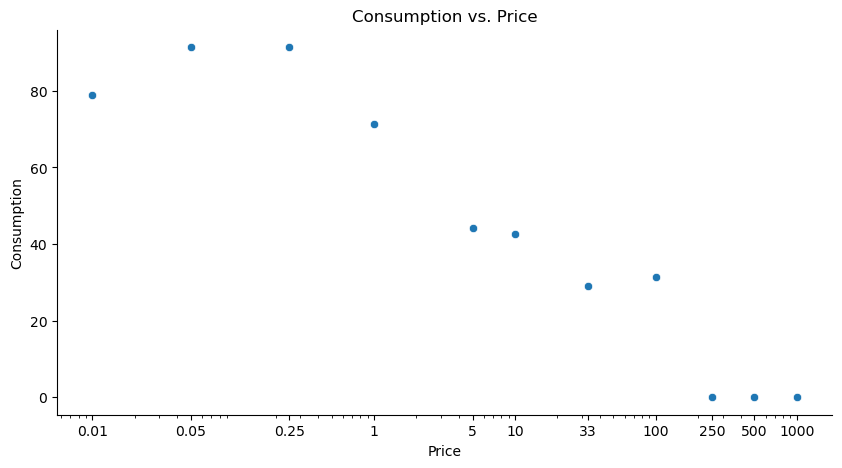

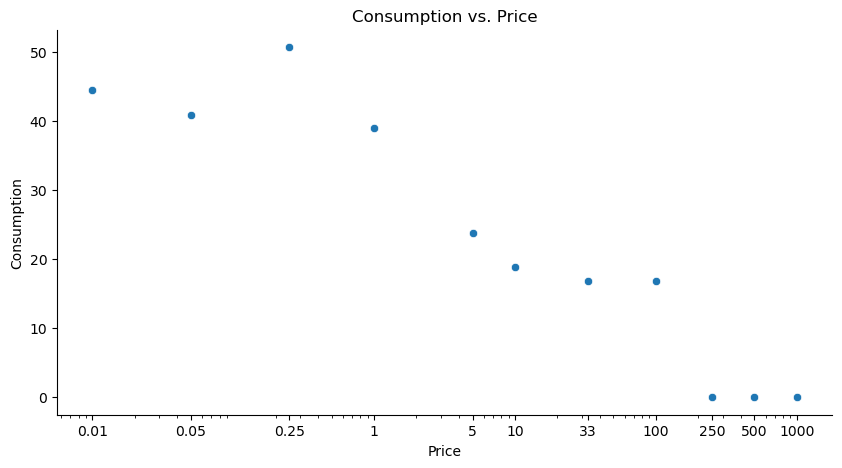

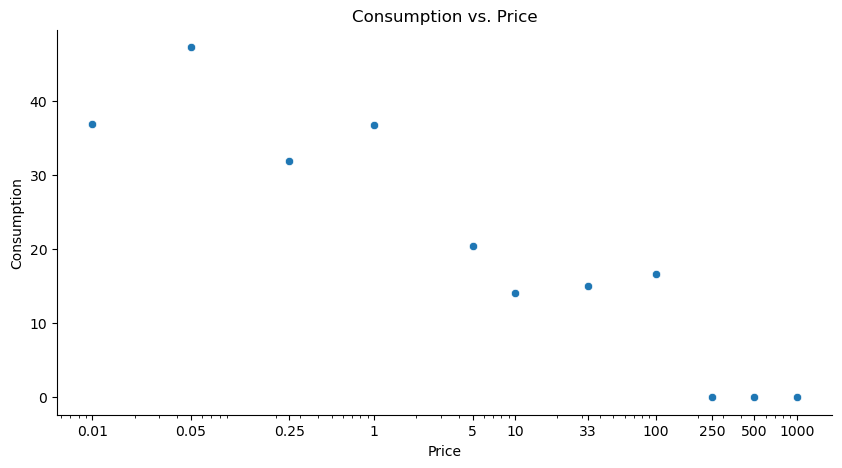

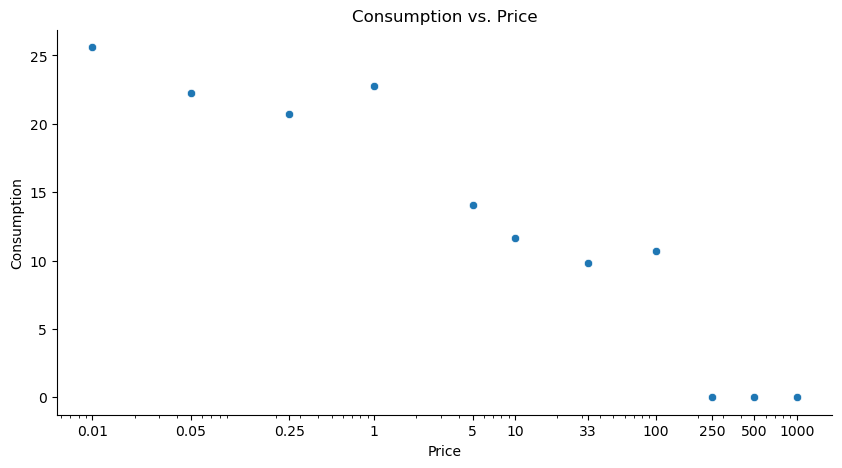

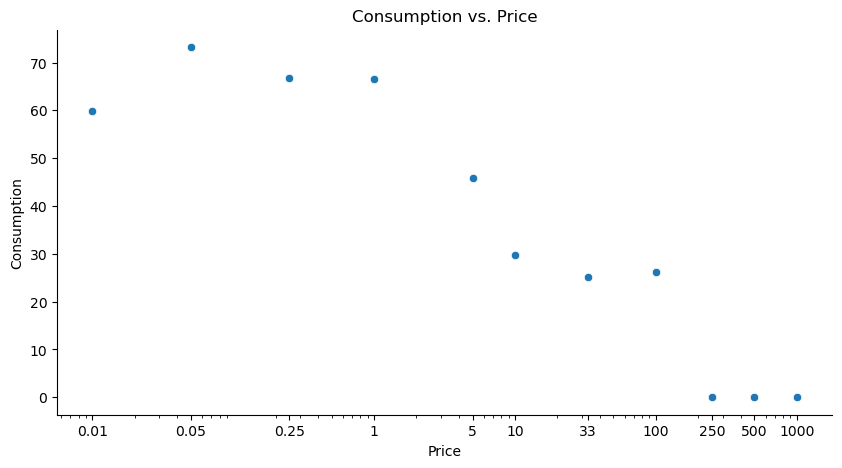

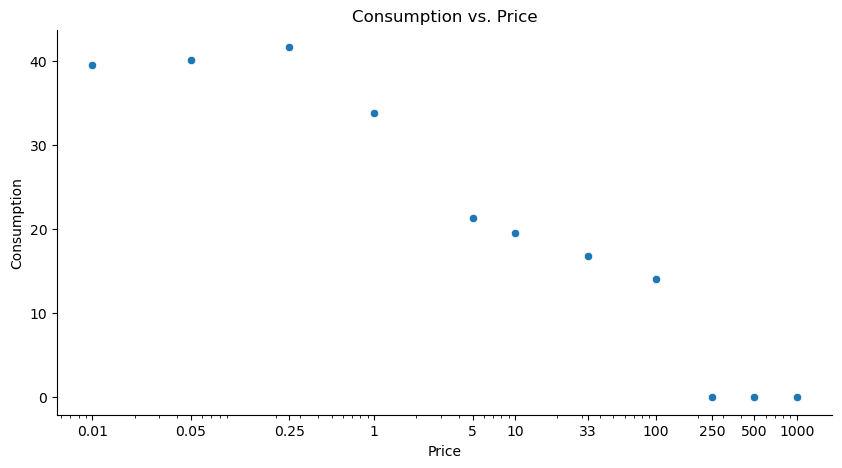

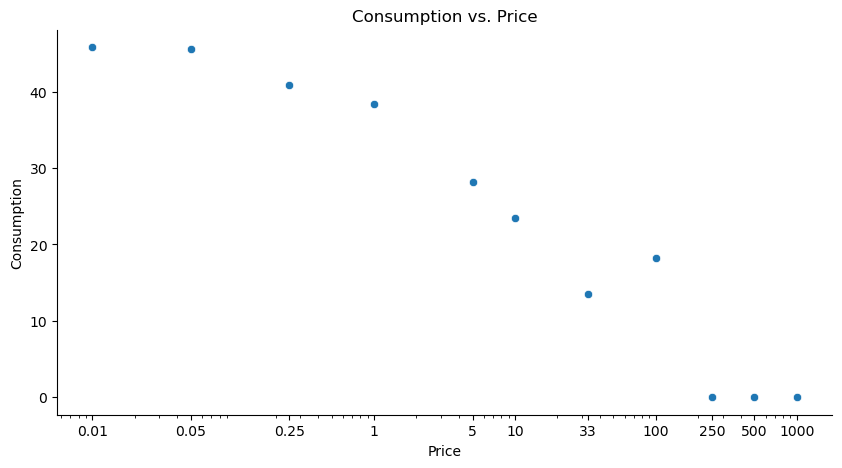

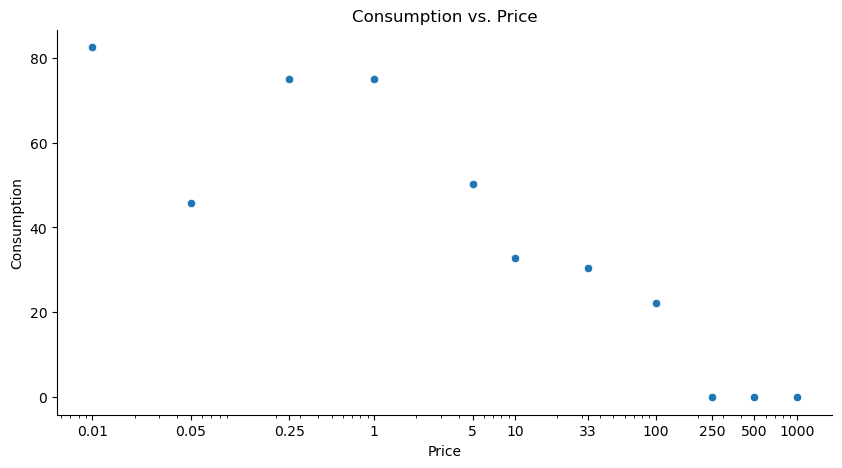

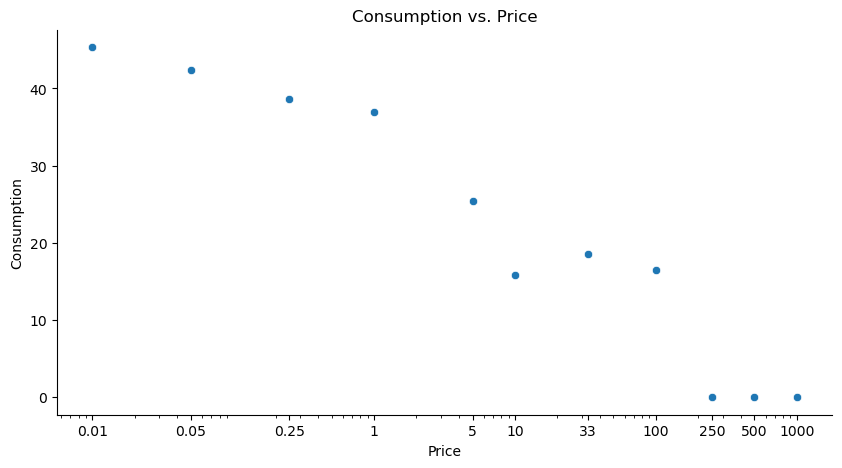

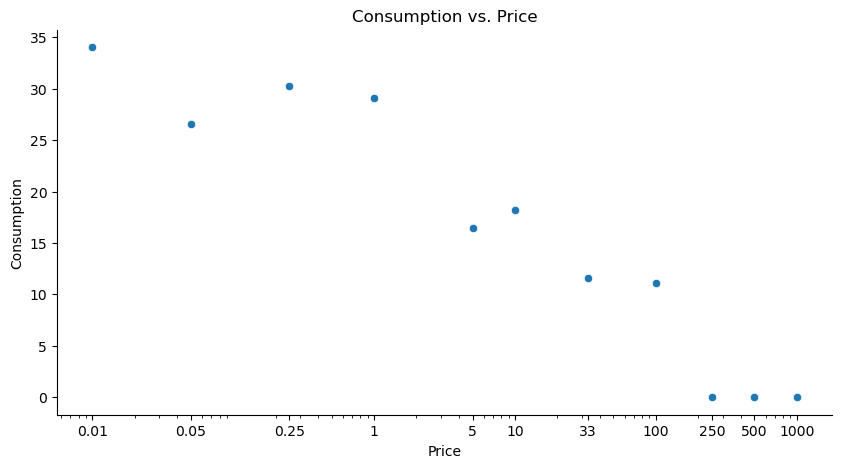

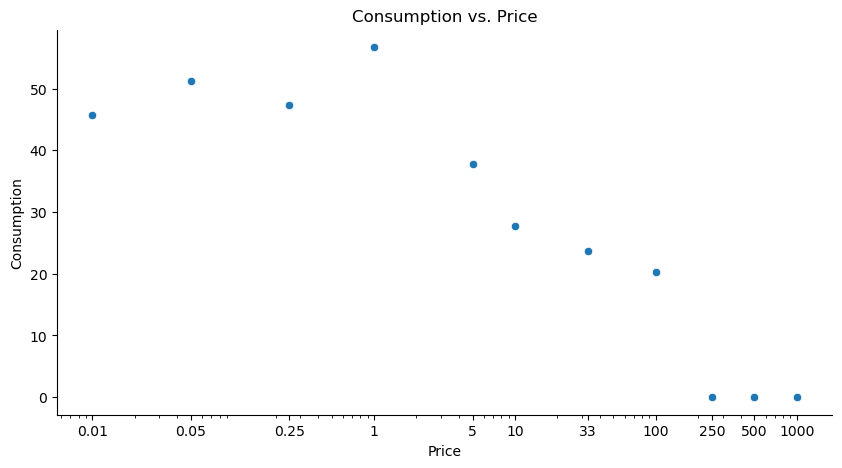

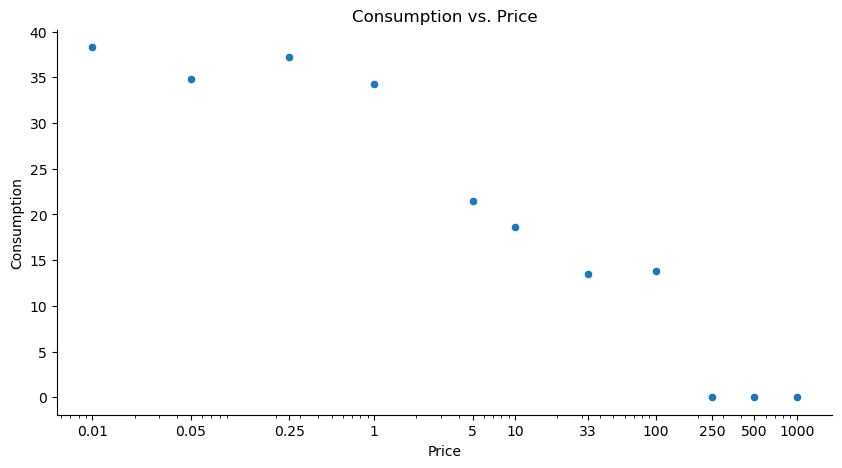

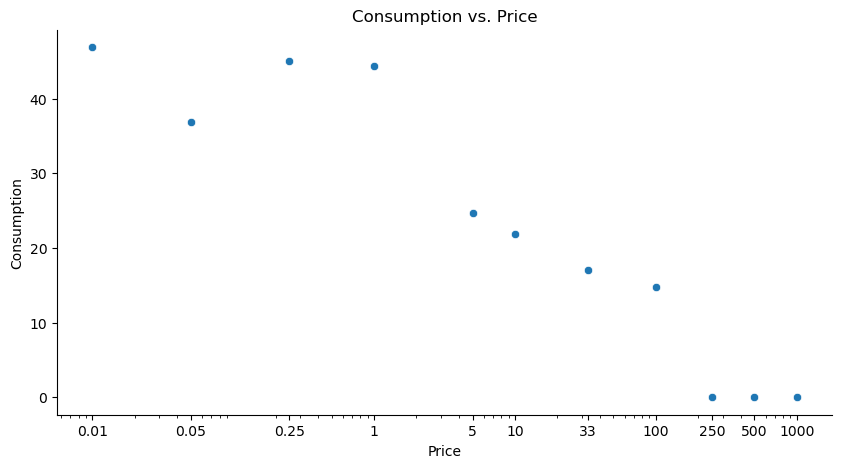

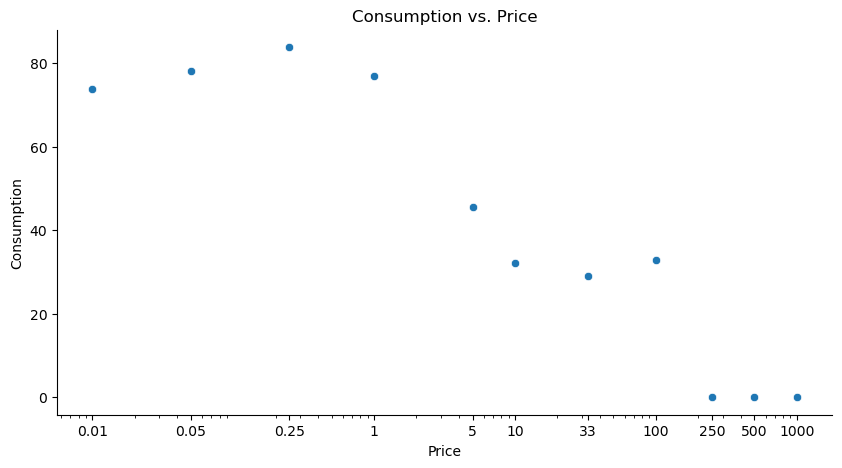

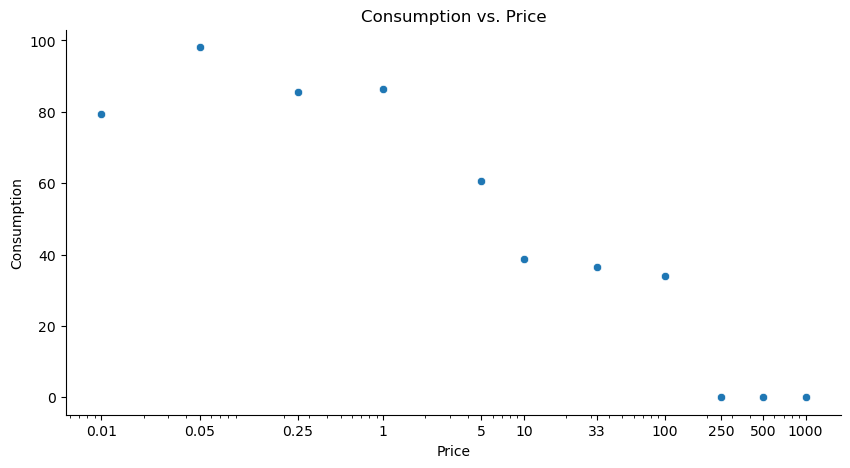

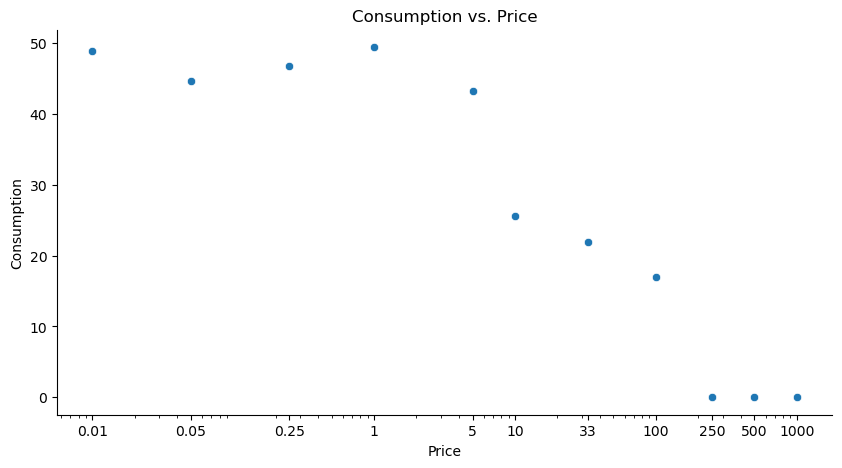

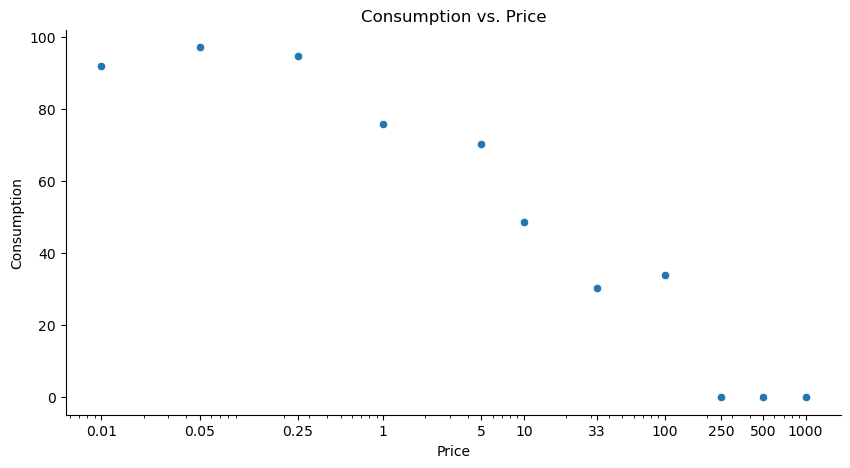

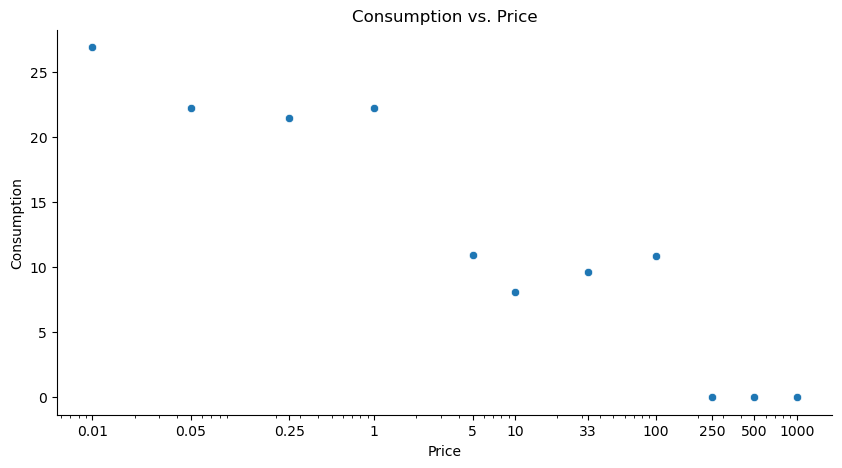

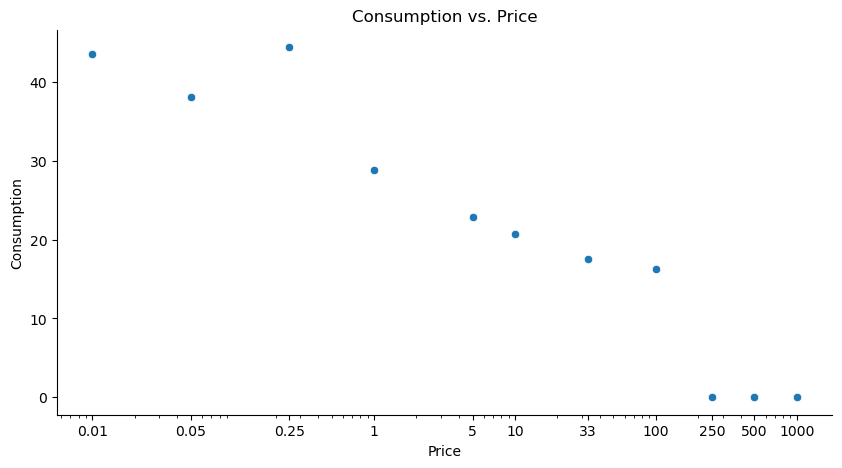

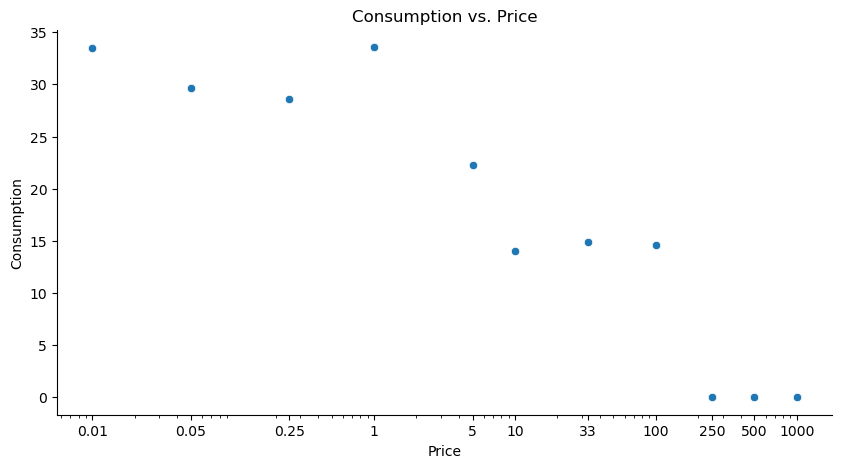

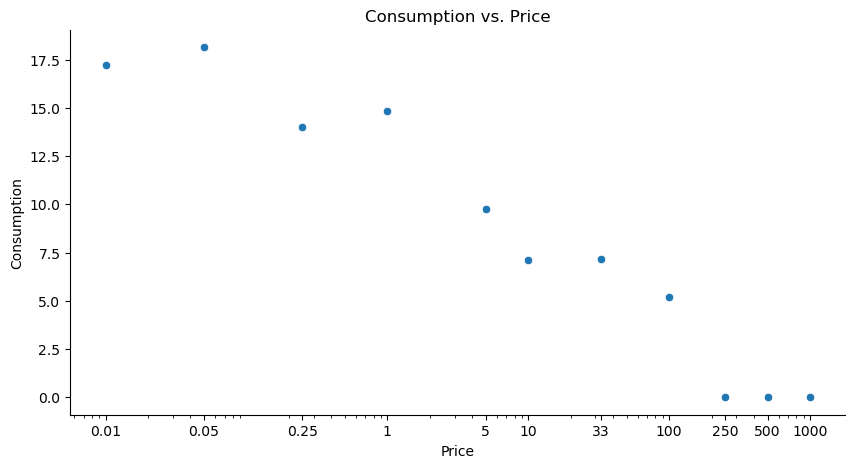

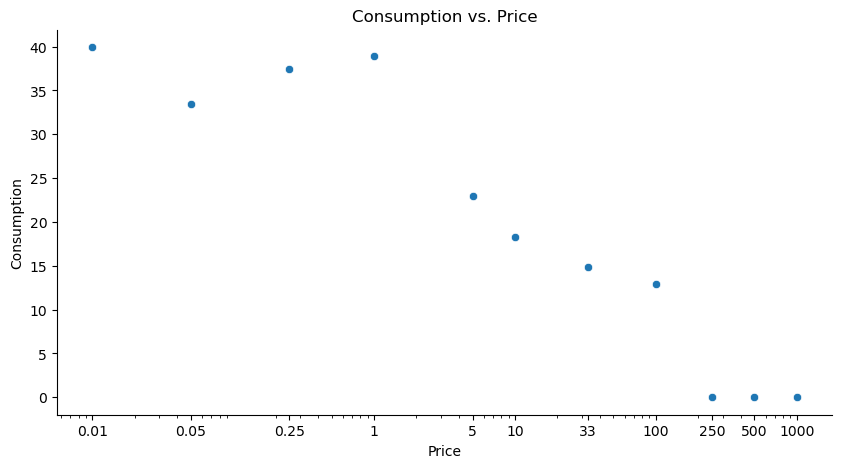

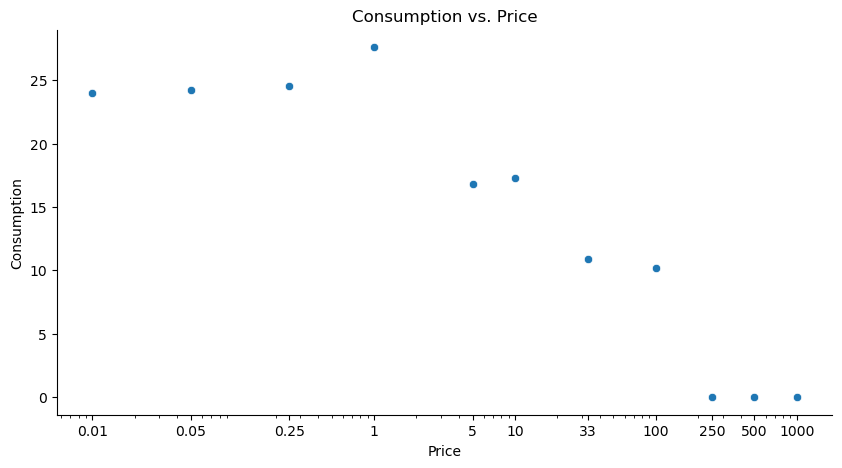

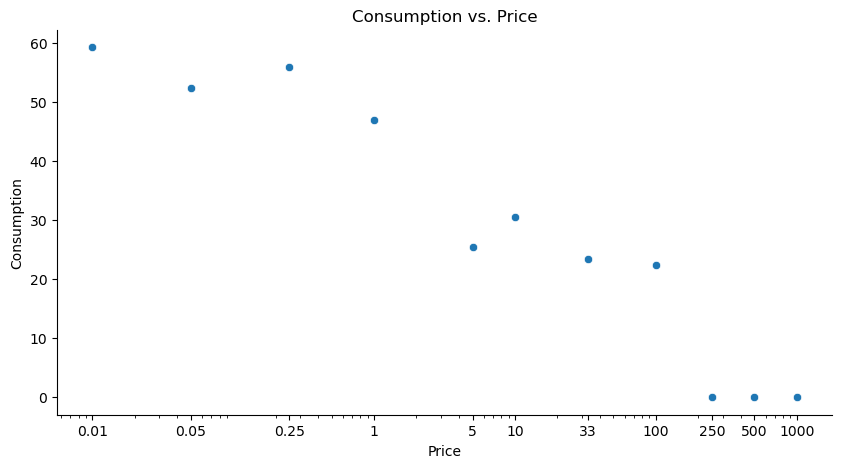

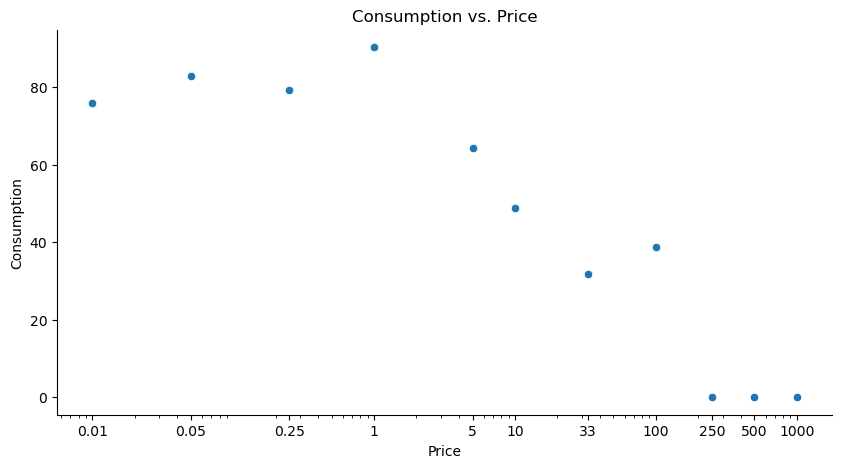

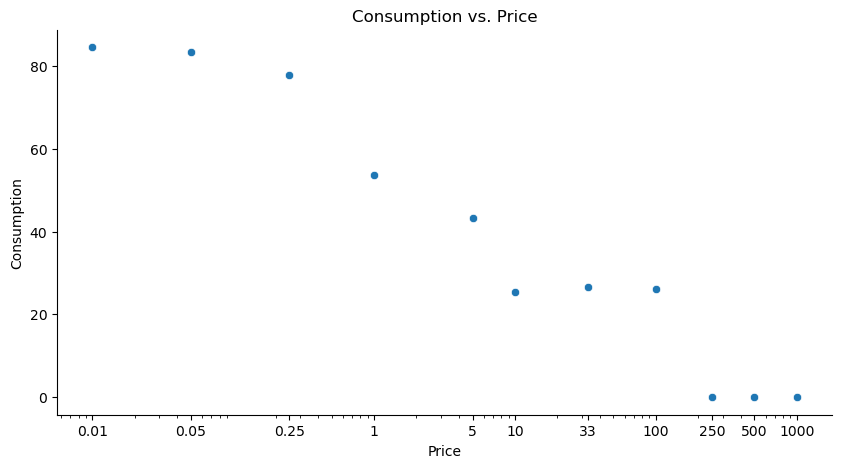

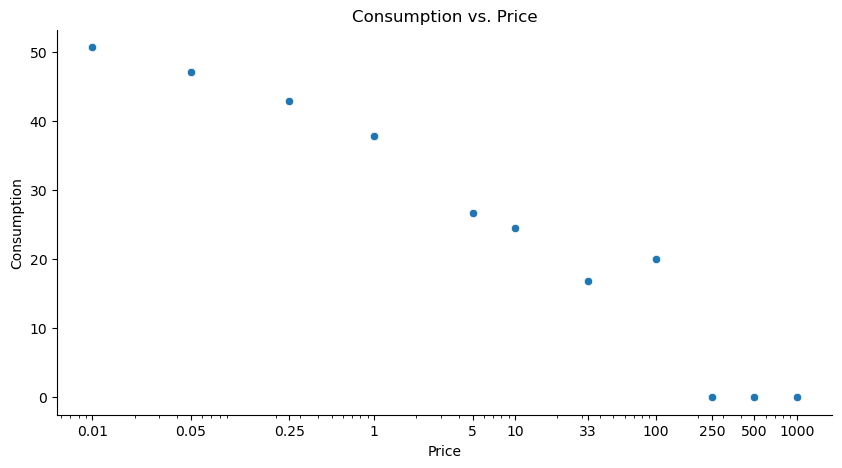

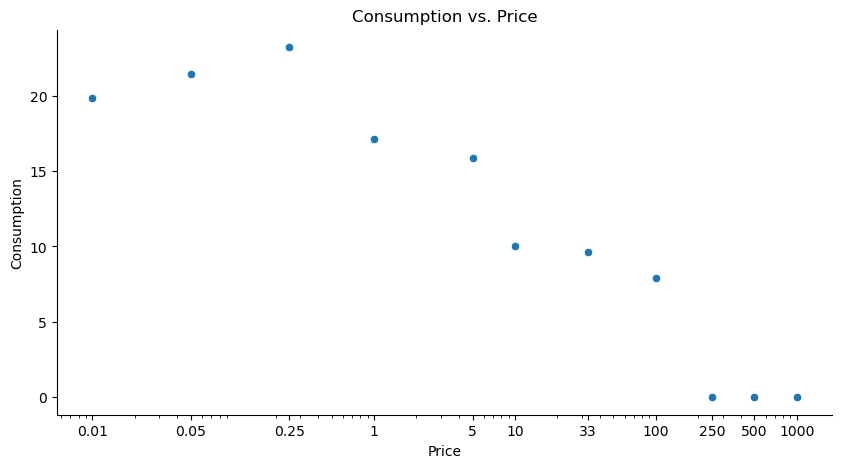

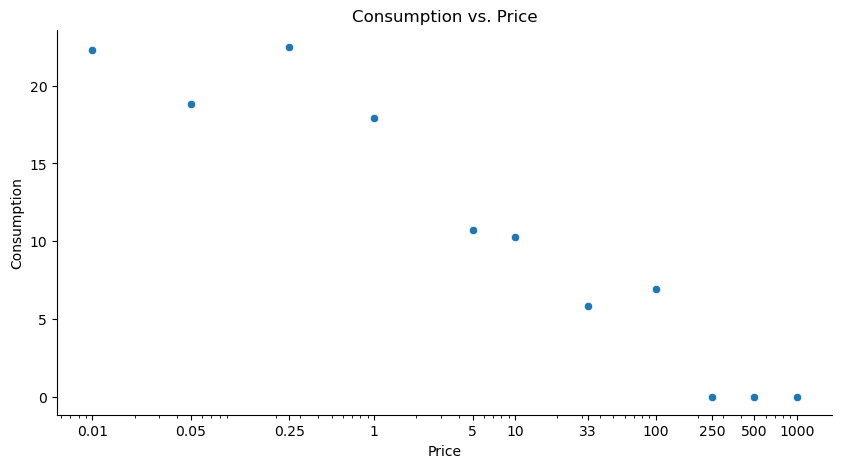

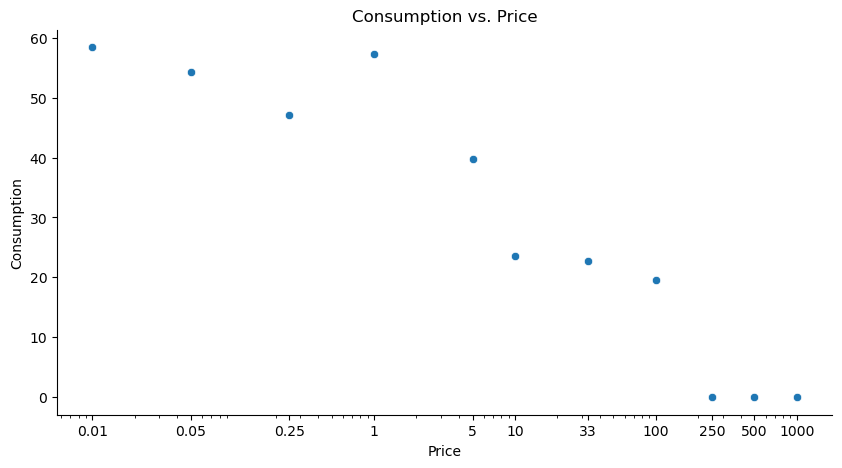

In [24]:
for participant in df['participant_id'].unique():
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.scatterplot(data=df[df['participant_id'] == participant], x='price', y='consumption', ax=ax)
    sns.despine(top=True,right=True)
    
    ax.set_xscale('log')
    ax.set_xlabel('Price')
    ax.set_ylabel('Consumption')
    # Set both the ticks and the labels
    ticks = [0.01, 0.05, 0.25, 1, 5, 10, 33, 100, 250, 500, 1000]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.set_title('Consumption vs. Price')
    plt.show()
